<a href="https://colab.research.google.com/github/SelenaHuynh/SelenaHuynh/blob/main/NLP_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
pal = sns.color_palette()

# **Import Data**

The selected dataset for this project is the vnPara dataset, developed by Ngo et al. (2015). It comprises 3 files:


*   *Sentences1.txt, Sentences2.txt*: Merging these 2 files side by side yields sentence pairs.
*   *Labels.txt*: It contains labels where 1 indicates the sentence pair as paraphrases, while 0 indicates they are not paraphrases.

## Level 1 Sentences

The code below imports Level 1 processing for the sentences in the vnPara dataset. In Level 1, sentences are imported exactly as written, keeping the original order of words and tokens.

In [ ]:
url_label = "https://raw.githubusercontent.com/nlp-team-itus-hcmc/paraphrase-identification-vietnamese-document/master/vnPara/Labels.txt"

url_sentence1_lv1 = "https://raw.githubusercontent.com/nlp-team-itus-hcmc/paraphrase-identification-vietnamese-document/master/extracted_sentences/abstract_sentences/level1/sentences_1_level_1.txt"
url_sentence2_lv1 = "https://raw.githubusercontent.com/nlp-team-itus-hcmc/paraphrase-identification-vietnamese-document/master/extracted_sentences/abstract_sentences/level1/sentences_2_level_1.txt"

# import files via their Github links
labels = pd.read_csv(url_label, names=["label"], sep="\t")
s1_lv1 = pd.read_csv(url_sentence1_lv1, names=["sentence1"])
s2_lv1 = pd.read_csv(url_sentence2_lv1, names=["sentence2"])

In [ ]:
labels['label'].value_counts()

label
1     1576
0     1506
1,       1
Name: count, dtype: int64

Upon inspection, there is one label value that are incorrectly formatted. This value is subsequently reformatted. The ratio between labels 0 and 1 is displayed below:

In [ ]:
labels["label"] = labels["label"].replace(",", "", regex=True)

vc = labels["label"].value_counts()

share_of_0 = vc[0] / (vc[0] + vc[1])
share_of_1 = vc[1] / (vc[0] + vc[1])

print("Share of label 0: {:.0f} --> {:.1%}".format(vc[0], share_of_0))
print("Share of label 1: {:.0f} --> {:.1%}".format(vc[1], share_of_1))

Share of label 0: 1577 --> 51.2%
Share of label 1: 1506 --> 48.8%


Concatenating 3 dataframes labels, sentence1_lv1, sentence2_lv1 into one dataframe

In [ ]:
df_lv1 = pd.concat([s1_lv1, s2_lv1, labels], axis=1)
df_lv1

,sentence1,sentence2,label
0,về nguyên nhân thất bại của u23 việt nam đã đư...,bản thân tổng giám đốc slna nguyễn hồng thanh ...,0
1,song có thể nói ngay rằng cuộc mổ xẻ tìm nguyê...,cả nền bóng đá việt nam đang khủng hoảng và đá...,0
2,đúng như câu nói của một vị quan chức vff tại ...,cả nền bóng đá việt nam đang khủng hoảng và đá...,0
3,trả lời câu hỏi này tôi xin nói lên suy nghĩ c...,sự thực 100 đội bóng chuyên nghiệp việt nam hi...,0
4,theo tôi trong lĩnh vực bóng đá nhà nghề đội t...,nếu mùa giải mới bắt đầu đúng hẹn thì vleague ...,0
...,...,...,...
3078,chẳng hạn nếu như bạn là người trung thực và a...,mối quan tâm hàng đầu của những người này là c...,0
3079,vì thế bạn cần phải biết cách thể hiện bản thâ...,để có được vị trí này bạn cần phải học tập rèn...,0
3080,bởi nó sẽ cung cấp cho bạn rất nhiều mẹo giúp ...,những vị khách hàng khó tính sẽ giúp bạn có th...,0
3081,có thể ở vào thời điểm này bạn sẽ thấy nó thật...,các khách hàng sẽ luôn cảm thấy thoải mái hơn ...,0


## Level 3 Sentences



Since there was trouble downloading the files of level 3 sentences from the Github source, we downloaded and uploaded them to the personal Github account.

This upload has been used for this project only and will be removed after the assessment.


In [ ]:
# Download the first file
!wget https://raw.githubusercontent.com/DuyQuangVo/sentencelv3/f43ec9717870f3c4e31f6f7b6a42ba2890566aa4/Sentences1-pp.txt.ws.pos -O /content/Sentences1-pp.txt.ws.pos

# Verify the file has been downloaded
!ls /content

# Load and read the first file into a list
sentence1_lv3 = []
with open("/content/Sentences1-pp.txt.ws.pos", 'r') as f1:
    for line in f1:
        sentence1_lv3.append(line.strip())

# Print the length of the list and the first element to verify
print(len(sentence1_lv3))
print(sentence1_lv3[0])


--2024-05-17 04:45:21--  https://raw.githubusercontent.com/DuyQuangVo/sentencelv3/f43ec9717870f3c4e31f6f7b6a42ba2890566aa4/Sentences1-pp.txt.ws.pos
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 891315 (870K) [text/plain]
Saving to: ‘/content/Sentences1-pp.txt.ws.pos’

/content/Sentences1 100%[===================>] 870.42K  --.-KB/s    in 0.01s   

2024-05-17 04:45:21 (75.9 MB/s) - ‘/content/Sentences1-pp.txt.ws.pos’ saved [891315/891315]

sample_data  Sentences1-pp.txt.ws.pos  Sentences2-pp.txt.ws.pos
3083
Về/Cm nguyên_nhân/Nn thất_bại/Vv của/Cm U23/Nr Việt_Nam/Nr đã/R được/Vv tìm/Vv ra/R :/PU "/PU Cầu_thủ/Nn mất/Ve phong_độ/Nn thi_đấu/Vv "/PU "/PU Chọn/Vv sai/Aa điểm/Nn rơi/Vv phong_độ/Nn "/PU "/PU Nhiều/Aa cầu_thủ/Nn trụ_cột/Nn bị/Vv chấn_thương/Aa "/PU 

In [ ]:
# Download the second file
!wget https://raw.githubusercontent.com/DuyQuangVo/sentencelv3/f43ec9717870f3c4e31f6f7b6a42ba2890566aa4/Sentences2-pp.txt.ws.pos -O /content/Sentences2-pp.txt.ws.pos

# Verify the file has been downloaded
!ls /content

# Load and read the second file into a list
sentence2_lv3 = []
with open("/content/Sentences2-pp.txt.ws.pos", 'r') as f2:
    for line in f2:
        sentence2_lv3.append(line.strip())

# Print the length of the list and the first element to verify
print(len(sentence2_lv3))
print(sentence2_lv3[0])


--2024-05-17 04:45:21--  https://raw.githubusercontent.com/DuyQuangVo/sentencelv3/f43ec9717870f3c4e31f6f7b6a42ba2890566aa4/Sentences2-pp.txt.ws.pos
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 965599 (943K) [text/plain]
Saving to: ‘/content/Sentences2-pp.txt.ws.pos’

/content/Sentences2 100%[===================>] 942.97K  --.-KB/s    in 0.01s   

2024-05-17 04:45:21 (81.3 MB/s) - ‘/content/Sentences2-pp.txt.ws.pos’ saved [965599/965599]

sample_data  Sentences1-pp.txt.ws.pos  Sentences2-pp.txt.ws.pos
3083
Bản_thân/Nn Tổng_giám_đốc/Nn SLNA/Nr Nguyễn_Hồng_Thanh/Nr đã/R phải/Vv kêu_gọi/Vv :/PU "/PU VFF/Nr có/Ve trách_nhiệm/Nn báo_cáo/Vv Bộ/Nn Văn_hoá/Nn -/PU Thể_thao/Nn và/Cp Du_lịch/Nn Chính_phủ/Nn để/Cm tìm/Vv ra/R hướng/Nn giải_cứu/Vv bóng_đá/Nn Việt_Nam/

In [ ]:
import re

def remove_special_characters(sentence):
  # remove the special character pattern "..." (3 or more consecutive dots)
  sentence = re.sub('v/Nn\s./PU\sv/Nn\s./PU\s./PU\s./PU', '', sentence, re.UNICODE)
  sentence = sentence.lower()
  # Remove all punctuation marks
  s = re.sub('\W/pu', '', sentence, re.UNICODE)
  # Replace any 2 consecutive white spaces with 1
  new_sentence = re.sub('\s{2,}', ' ', s, re.UNICODE)
  return new_sentence

In [ ]:
for i in range(len(sentence1_lv3)):
  s1 = remove_special_characters(sentence1_lv3[i])
  s2 = remove_special_characters(sentence2_lv3[i])
  sentence1_lv3[i] = s1
  sentence2_lv3[i] = s2

In [ ]:
sentence1_lv3[0]

'về/cm nguyên_nhân/nn thất_bại/vv của/cm u23/nr việt_nam/nr đã/r được/vv tìm/vv ra/r cầu_thủ/nn mất/ve phong_độ/nn thi_đấu/vv chọn/vv sai/aa điểm/nn rơi/vv phong_độ/nn nhiều/aa cầu_thủ/nn trụ_cột/nn bị/vv chấn_thương/aa lịch/nr thi_đấu/vv thiếu/aa khoa_học/nn thiếu/aa hiểu_biết/nn về/cm đối_thủ/nn có/ve sai_lầm/nn về/cm chiến_thuật/nn bản_lĩnh/nn thi_đấu/vv yếu_kém/aa '

## Create Level 4 from Level 3 Sentences

In [ ]:
# These functions detect whether each given word is a noun, a verb, or an adjective

def is_noun(word):
  # all variations of noun POS
  type_nouns = ['/nn', '/nu', '/nq', '/nt', '/nr']
  for type_noun in type_nouns:
    if word.find(type_noun) != -1:
      return True
  return False

def is_verb(word):
  # all variations of verb POS
  type_verbs = ['/vd', '/vv', '/vc', '/ve']
  for type_verb in type_verbs:
    if word.find(type_verb) != -1:
      return True
  return False

def is_adj(word):
  if (word.find('/aa') != -1):
    return True
  return False

In [ ]:
# This function remove all words that are not nouns, verbs, or adjectives

def keep_noun_verb_adj(sentence):
  # split a sentence into a list of words
  words = sentence.split(' ')
  # create a new_sentence placeholder
  new_sentence = ''
  # for each word in the words list
  for word in words:
    # if it is a noun/ verb/ adjective, append to new_setence
    if (is_noun(word)) or (is_verb(word)) or (is_adj(word)):
      new_sentence = new_sentence + word + ' '
  return new_sentence

In [ ]:
list_lv4 = []

for i in range(len(sentence1_lv3)):
  s1_level4 = keep_noun_verb_adj(sentence1_lv3[i])
  s2_level4 = keep_noun_verb_adj(sentence2_lv3[i])
  s = {'sentence1': s1_level4, 'sentence2': s2_level4}
  list_lv4.append(s)

In [ ]:
df_lv4 = pd.DataFrame(list_lv4)
df_lv4 = pd.concat([df_lv4, labels], axis=1)
df_lv4

,sentence1,sentence2,label
0,nguyên_nhân/nn thất_bại/vv u23/nr việt_nam/nr ...,bản_thân/nn tổng_giám_đốc/nn slna/nr nguyễn_hồ...,0
1,có_thể/aa nói/vv mổ_xẻ/vv tìm/vv nguyên_nhân/n...,bóng_đá/nn việt_nam/nr khủng_hoảng/vv đáng/vv ...,0
2,đúng/aa câu/nn nói/vv một/nq quan_chức/nn vff/...,bóng_đá/nn việt_nam/nr khủng_hoảng/vv đáng/vv ...,0
3,trả_lời/vv câu/nn hỏi/vv xin/vv nói_lên/vv suy...,sự_thực/nn 100/nq %/nu đội/nn bóng/nn chuyên_n...,0
4,theo/vv lĩnh_vực/nn bóng_đá/nn nhà_nghề/nn đội...,mùa/nn giải/nn bắt_đầu/vv đúng/aa hẹn/nn có/ve...,0
...,...,...,...
3078,là/vc người/nn trung_thực/aa am_hiểu/vv tài_ch...,quan_tâm/vv hàng_đầu/nn những/nq người/nn là/v...,0
3079,cần/vv phải/vv biết/vv cách/nn thể_hiện/vv bản...,có/ve vị_trí/nn cần/vv phải/vv học_tập/vv rèn_...,0
3080,cung_cấp/vv nhiều/aa mẹo/nn giúp/vv lấy/vv khá...,những/nq khách_hàng/nn khó_tính/aa giúp/vv có/...,0
3081,có_thể/aa thời_điểm/nt thấy/vv vô_bổ/aa về/vv ...,các/nq khách_hàng/nn cảm_thấy/vv thoải_mái/aa ...,0


In [ ]:
df_lv4['sentence1'].loc[0]

'nguyên_nhân/nn thất_bại/vv u23/nr việt_nam/nr được/vv tìm/vv cầu_thủ/nn mất/ve phong_độ/nn thi_đấu/vv chọn/vv sai/aa điểm/nn rơi/vv phong_độ/nn nhiều/aa cầu_thủ/nn trụ_cột/nn bị/vv chấn_thương/aa lịch/nr thi_đấu/vv thiếu/aa khoa_học/nn thiếu/aa hiểu_biết/nn đối_thủ/nn có/ve sai_lầm/nn chiến_thuật/nn bản_lĩnh/nn thi_đấu/vv yếu_kém/aa '

In [ ]:
df_lv1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3083 entries, 0 to 3082
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentence1  3083 non-null   object
 1   sentence2  3083 non-null   object
 2   label      3083 non-null   object
dtypes: object(3)
memory usage: 72.4+ KB


In [ ]:
df_lv4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3083 entries, 0 to 3082
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentence1  3083 non-null   object
 1   sentence2  3083 non-null   object
 2   label      3083 non-null   object
dtypes: object(3)
memory usage: 72.4+ KB


# **Feature Extraction**

## Simple Features

Create simple features out of each sentence pair:


*   **common_words**: number of common words between sentence 1 and 2
*   **total_words**: total number of words between sentence 1 and 2
*   **common_ratio**: ratio of **common_words** to **total_words**
*   **last_word_common**: equals 1 if sentence 1 and 2 have the same last word, 0 if they have different last word
*   **first_word_common**: equals 1 if sentence 1 and 2 have the same first word, 0 if they have different first word
*   **s1len**: number of characters in sentence 1
*   **s2len**: number of characters in sentence 2
*   **len_diff**: absolute difference between **s1len** and **s2len**
*   **s1_n_words**: number of words in sentence 1
*   **s2_n_words**: number of words in sentence 2
*   **n_words_diff**: absolute difference between **s1_n_words** and **s2_n_words**











In [ ]:
def common_words(row):
  w1 = set(map(lambda word: word.lower().strip(), row['sentence1'].split(" ")))
  w2 = set(map(lambda word: word.lower().strip(), row['sentence2'].split(" ")))
  common_words = 1.0 * len(w1 & w2)
  total_words = 1.0 * (len(w1) + len(w2))
  common_ratio = common_words / total_words

  s1 = row['sentence1'].strip().split(" ")
  s2 = row['sentence2'].strip().split(" ")
  last_word_common  = 1 if s1[-1] == s2[-1] else 0
  first_word_common = 1 if s1[0]  == s2[0]  else 0

  return common_words, total_words, common_ratio, last_word_common, first_word_common

In [ ]:
def simple_features(df):
  df['s1len'] = df['sentence1'].str.len()
  df['s2len'] = df['sentence2'].str.len()
  df['len_diff'] = abs(df['s1len'] - df['s2len'])
  df['s1_n_words'] = df['sentence1'].apply(lambda row: len(row.split(" ")))
  df['s2_n_words'] = df['sentence2'].apply(lambda row: len(row.split(" ")))
  df['n_words_diff'] = abs(df['s1_n_words'] - df['s2_n_words'])

  df[["common_words", "total_words", "common_ratio", "last_word_common", "first_word_common"]] = df.apply(common_words, axis=1, result_type="expand")
  return df

Create simple features for both Level 1 and Level 4 datasets.

In [ ]:
df_lv1 = simple_features(df_lv1)
df_lv1.head(3)

,sentence1,sentence2,label,s1len,s2len,len_diff,s1_n_words,s2_n_words,n_words_diff,common_words,total_words,common_ratio,last_word_common,first_word_common
0,về nguyên nhân thất bại của u23 việt nam đã đư...,bản thân tổng giám đốc slna nguyễn hồng thanh ...,0,255,172,83,59,40,19,9.0,86.0,0.104651,0.0,0.0
1,song có thể nói ngay rằng cuộc mổ xẻ tìm nguyê...,cả nền bóng đá việt nam đang khủng hoảng và đá...,0,122,112,10,28,26,2,9.0,51.0,0.176471,0.0,0.0
2,đúng như câu nói của một vị quan chức vff tại ...,cả nền bóng đá việt nam đang khủng hoảng và đá...,0,184,112,72,42,26,16,9.0,66.0,0.136364,0.0,0.0


In [ ]:
df_lv4 = simple_features(df_lv4)
df_lv4.head(3)

,sentence1,sentence2,label,s1len,s2len,len_diff,s1_n_words,s2_n_words,n_words_diff,common_words,total_words,common_ratio,last_word_common,first_word_common
0,nguyên_nhân/nn thất_bại/vv u23/nr việt_nam/nr ...,bản_thân/nn tổng_giám_đốc/nn slna/nr nguyễn_hồ...,0,335,220,115,34,21,13,4.0,50.0,0.080000,0.0,0.0
1,có_thể/aa nói/vv mổ_xẻ/vv tìm/vv nguyên_nhân/n...,bóng_đá/nn việt_nam/nr khủng_hoảng/vv đáng/vv ...,0,106,115,9,11,13,2,4.0,23.0,0.173913,0.0,0.0
2,đúng/aa câu/nn nói/vv một/nq quan_chức/nn vff/...,bóng_đá/nn việt_nam/nr khủng_hoảng/vv đáng/vv ...,0,211,115,96,25,13,12,5.0,37.0,0.135135,0.0,0.0


## Advanced Features

In [ ]:
!pip install distance
import distance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for distance: filename=Distance-0.1.3-py3-none-any.whl size=16258 sha256=bc48376c0d7125afb3017169b12b40af4648d0143813d2bd18d3a22c5982f419
  Stored in directory: /root/.cache/pip/wheels/e8/bb/de/f71bf63559ea9a921059a5405806f7ff6ed612a9231c4a9309
Successfully built distance


### Longest Common Substring

Return the longest common substring (LCS) between sentence 1 and sentence 2, and the ratio of LCS and the minimum sentence length between 2 sentences.

In [ ]:
# Example of longest common substring
a = df_lv1['sentence1'].loc[0]
b = df_lv1['sentence2'].loc[0]
print(a)
print(b)
lcs = list(distance.lcsubstrings(a, b))
print("Longest common substring: ", lcs[0])
print(len(lcs[0]))
print(len(lcs[0]) / (min(len(a), len(b)) + 1))

về nguyên nhân thất bại của u23 việt nam đã được tìm ra cầu thủ mất phong độ thi đấu chọn sai điểm rơi phong độ nhiều cầu thủ trụ cột bị chấn thương lịch thi đấu thiếu khoa học thiếu hiểu biết về đối thủ có sai lầm về chiến thuật bản lĩnh thi đấu yếu kém 
bản thân tổng giám đốc slna nguyễn hồng thanh đã phải kêu gọi vff có trách nhiệm báo cáo bộ văn hóa thể thao và du lịch chính phủ để tìm ra hướng giải cứu bóng đá việt nam 
Longest common substring:   việt nam 
10
0.057803468208092484


In [ ]:
def longest_common_substring(s1, s2):
    lcs = list(distance.lcsubstrings(s1, s2))
    if len(lcs) == 0:
        return 0
    else:
        return len(lcs[0]), len(lcs[0]) / (min(len(s1), len(s2)) + 1)

In [ ]:
features = df_lv1.apply(lambda x: longest_common_substring(x["sentence1"], x["sentence2"]), axis=1)

df_lv1["lcs_length"] = list(map(lambda x: x[0], features))
df_lv1["lcs_ratio"] = list(map(lambda x: x[1], features))
df_lv1.head(3)

,sentence1,sentence2,label,s1len,s2len,len_diff,s1_n_words,s2_n_words,n_words_diff,common_words,total_words,common_ratio,last_word_common,first_word_common,lcs_length,lcs_ratio
0,về nguyên nhân thất bại của u23 việt nam đã đư...,bản thân tổng giám đốc slna nguyễn hồng thanh ...,0,255,172,83,59,40,19,9.0,86.0,0.104651,0.0,0.0,10,0.057803
1,song có thể nói ngay rằng cuộc mổ xẻ tìm nguyê...,cả nền bóng đá việt nam đang khủng hoảng và đá...,0,122,112,10,28,26,2,9.0,51.0,0.176471,0.0,0.0,10,0.088496
2,đúng như câu nói của một vị quan chức vff tại ...,cả nền bóng đá việt nam đang khủng hoảng và đá...,0,184,112,72,42,26,16,9.0,66.0,0.136364,0.0,0.0,23,0.203540


In [ ]:
features = df_lv4.apply(lambda x: longest_common_substring(x["sentence1"], x["sentence2"]), axis=1)

df_lv4["lcs_length"] = list(map(lambda x: x[0], features))
df_lv4["lcs_ratio"] = list(map(lambda x: x[1], features))
df_lv4.head(3)

,sentence1,sentence2,label,s1len,s2len,len_diff,s1_n_words,s2_n_words,n_words_diff,common_words,total_words,common_ratio,last_word_common,first_word_common,lcs_length,lcs_ratio
0,nguyên_nhân/nn thất_bại/vv u23/nr việt_nam/nr ...,bản_thân/nn tổng_giám_đốc/nn slna/nr nguyễn_hồ...,0,335,220,115,34,21,13,4.0,50.0,0.080000,0.0,0.0,13,0.058824
1,có_thể/aa nói/vv mổ_xẻ/vv tìm/vv nguyên_nhân/n...,bóng_đá/nn việt_nam/nr khủng_hoảng/vv đáng/vv ...,0,106,115,9,11,13,2,4.0,23.0,0.173913,0.0,0.0,13,0.121495
2,đúng/aa câu/nn nói/vv một/nq quan_chức/nn vff/...,bóng_đá/nn việt_nam/nr khủng_hoảng/vv đáng/vv ...,0,211,115,96,25,13,12,5.0,37.0,0.135135,0.0,0.0,23,0.198276


### Levenshtein Distance

The Levenshtein Distance represents the level of similarity between 2 sentences. In essence, it measures the minimum number of single-character edits (insertions, deletions, or substitutions) required to change one sequence into another.

Normalization is done by dividing the Levenshtein Distance by the length of the longer sentence. This yields a value between 0 and 1, where 0 indicates identical sequences and 1 indicates completely dissimilar sequences.

In [ ]:
# Example of Levenshtein Distance

print(a)
print(b)
print("Levenshtein Distance: ", distance.nlevenshtein(a,b))

về nguyên nhân thất bại của u23 việt nam đã được tìm ra cầu thủ mất phong độ thi đấu chọn sai điểm rơi phong độ nhiều cầu thủ trụ cột bị chấn thương lịch thi đấu thiếu khoa học thiếu hiểu biết về đối thủ có sai lầm về chiến thuật bản lĩnh thi đấu yếu kém 
bản thân tổng giám đốc slna nguyễn hồng thanh đã phải kêu gọi vff có trách nhiệm báo cáo bộ văn hóa thể thao và du lịch chính phủ để tìm ra hướng giải cứu bóng đá việt nam 
Levenshtein Distance:  0.7019607843137254


In [ ]:
df_lv1["levenshtein"] = df_lv1.apply(lambda x: distance.nlevenshtein(x["sentence1"], x["sentence2"]), axis=1)
df_lv1.head(3)

,sentence1,sentence2,label,s1len,s2len,len_diff,s1_n_words,s2_n_words,n_words_diff,common_words,total_words,common_ratio,last_word_common,first_word_common,lcs_length,lcs_ratio,levenshtein
0,về nguyên nhân thất bại của u23 việt nam đã đư...,bản thân tổng giám đốc slna nguyễn hồng thanh ...,0,255,172,83,59,40,19,9.0,86.0,0.104651,0.0,0.0,10,0.057803,0.701961
1,song có thể nói ngay rằng cuộc mổ xẻ tìm nguyê...,cả nền bóng đá việt nam đang khủng hoảng và đá...,0,122,112,10,28,26,2,9.0,51.0,0.176471,0.0,0.0,10,0.088496,0.721311
2,đúng như câu nói của một vị quan chức vff tại ...,cả nền bóng đá việt nam đang khủng hoảng và đá...,0,184,112,72,42,26,16,9.0,66.0,0.136364,0.0,0.0,23,0.203540,0.755435


In [ ]:
df_lv4["levenshtein"] = df_lv1.apply(lambda x: distance.nlevenshtein(x["sentence1"], x["sentence2"]), axis=1)
df_lv4.head(3)

,sentence1,sentence2,label,s1len,s2len,len_diff,s1_n_words,s2_n_words,n_words_diff,common_words,total_words,common_ratio,last_word_common,first_word_common,lcs_length,lcs_ratio,levenshtein
0,nguyên_nhân/nn thất_bại/vv u23/nr việt_nam/nr ...,bản_thân/nn tổng_giám_đốc/nn slna/nr nguyễn_hồ...,0,335,220,115,34,21,13,4.0,50.0,0.080000,0.0,0.0,13,0.058824,0.701961
1,có_thể/aa nói/vv mổ_xẻ/vv tìm/vv nguyên_nhân/n...,bóng_đá/nn việt_nam/nr khủng_hoảng/vv đáng/vv ...,0,106,115,9,11,13,2,4.0,23.0,0.173913,0.0,0.0,13,0.121495,0.721311
2,đúng/aa câu/nn nói/vv một/nq quan_chức/nn vff/...,bóng_đá/nn việt_nam/nr khủng_hoảng/vv đáng/vv ...,0,211,115,96,25,13,12,5.0,37.0,0.135135,0.0,0.0,23,0.198276,0.755435


### Sentence Embedding
Word embedding is a technique used in natural language processing to represent words as dense vectors in a continuous vector space, capturing semantic relationships between words.

Installing dependencies

In [ ]:
%pip install -U --no-cache-dir gdown --pre

  Attempting uninstall: gdown
    Found existing installation: gdown 5.1.0
    Uninstalling gdown-5.1.0:
      Successfully uninstalled gdown-5.1.0


In [ ]:
!gdown https://drive.google.com/a/gm.uit.edu.vn/uc?id=1pXJZ9eHp6DWkQ5MhCzmWYsKyLQEDiodz&export=download
!tar xzf /content/vn_sbert_deploy.tar.gz

Downloading...
From (original): https://drive.google.com/a/gm.uit.edu.vn/uc?id=1pXJZ9eHp6DWkQ5MhCzmWYsKyLQEDiodz
From (redirected): https://drive.google.com/a/gm.uit.edu.vn/uc?id=1pXJZ9eHp6DWkQ5MhCzmWYsKyLQEDiodz&confirm=t&uuid=4f9cc23e-481e-4e94-9f64-6dc0f7a28277
To: /content/vn_sbert_deploy.tar.gz
100% 485M/485M [00:05<00:00, 88.0MB/s]


In [ ]:
!pip -q install transformers
!pip -q install vncorenlp
!pip -q install fairseq
!pip -q install fastBPE

!pip -q install fastapi
!pip -q install uvicorn
!pip -q install pyngrok
!pip -q install pyyaml==5.4.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 11.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 20.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.8/123.8 kB 13.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 11.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.3/288.3 kB 23.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.4/112.4 kB 12.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.

In [ ]:
!mkdir -p vncorenlp/models/wordsegmenter
!wget -q --show-progress https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.1.1.jar
!wget -q --show-progress https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/vi-vocab
!wget -q --show-progress https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/wordsegmenter.rdr
!mv VnCoreNLP-1.1.1.jar vncorenlp/
!mv vi-vocab vncorenlp/models/wordsegmenter/
!mv wordsegmenter.rdr vncorenlp/models/wordsegmenter/

VnCoreNLP-1.1.1.jar 100%[===================>]  26.14M  --.-KB/s    in 0.08s   
vi-vocab            100%[===================>] 514.20K  --.-KB/s    in 0.009s  
wordsegmenter.rdr   100%[===================>] 125.50K  --.-KB/s    in 0.005s  


In [ ]:
!git clone https://github.com/DatCanCode/sentence-transformers
!cd sentence-transformers; pip install -e .

Cloning into 'sentence-transformers'...
remote: Enumerating objects: 1200, done.
remote: Total 1200 (delta 0), reused 0 (delta 0), pack-reused 1200
Receiving objects: 100% (1200/1200), 30.77 MiB | 35.56 MiB/s, done.
Resolving deltas: 100% (817/817), done.
Obtaining file:///content/sentence-transformers
  Preparing metadata (setup.py) ... done
  Running setup.py develop for sentence-transformers


In [ ]:
%cd /content/sentence-transformers/
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('/content/vn_sbert_deploy/phobert_base_mean_tokens_NLI_STS')

/content/sentence-transformers


In [ ]:
#Append sentences to list
sentence_list = df_lv1[['sentence1','sentence2']].values.tolist()
sentences = []

for sl in sentence_list:
    for s in sl:
        sentences.append(s)

In [ ]:
#Encode Sentences to Corpus Embeddings
corpus_embeddings = model.encode(sentences)
np.array(corpus_embeddings).shape

(6166, 768)

Reduce Dimensions

In [ ]:
# Use PCA to reduce dimensions
from sklearn.decomposition import PCA
X = np.array(corpus_embeddings)

pca = PCA(n_components=5)
result = pca.fit_transform(X)

In [ ]:
#Result contains the embeddings
# Create lists to store embeddings for embedding 1 and embedding 2
embedding_1 = []
embedding_2 = []

# Iterate over the index positions of corpus_embeddings
for idx in range(len(result)):
    # Check if the index position is even (0, 2, 4, ...)
    if idx % 2 == 0:
        # Assign the embedding to embedding 1
        embedding_1.append(result[idx])
    else:
        # Assign the embedding to embedding 2
        embedding_2.append(result[idx])

In [ ]:
# Assign the embeddings to df_lv1 columns
df_lv1['embedding 1'] = embedding_1
df_lv1['embedding 2'] = embedding_2

df_lv1

,sentence1,sentence2,label,s1len,s2len,len_diff,s1_n_words,s2_n_words,n_words_diff,common_words,total_words,common_ratio,last_word_common,first_word_common,lcs_length,lcs_ratio,levenshtein,embedding 1,embedding 2
0,về nguyên nhân thất bại của u23 việt nam đã đư...,bản thân tổng giám đốc slna nguyễn hồng thanh ...,0,255,172,83,59,40,19,9.0,86.0,0.104651,0.0,0.0,10,0.057803,0.701961,"[-3.6769857, 0.24336182, -1.1788791, -0.584887...","[0.23530726, -1.6329713, -0.5481091, -0.484142..."
1,song có thể nói ngay rằng cuộc mổ xẻ tìm nguyê...,cả nền bóng đá việt nam đang khủng hoảng và đá...,0,122,112,10,28,26,2,9.0,51.0,0.176471,0.0,0.0,10,0.088496,0.721311,"[-4.2068095, -0.66777575, -1.3035204, -0.63683...","[-2.5454698, -0.18960036, -3.6362312, -0.50280..."
2,đúng như câu nói của một vị quan chức vff tại ...,cả nền bóng đá việt nam đang khủng hoảng và đá...,0,184,112,72,42,26,16,9.0,66.0,0.136364,0.0,0.0,23,0.203540,0.755435,"[0.7555827, -2.1135514, -1.1614949, 0.7149968,...","[-2.5454717, -0.18960103, -3.6362247, -0.50279..."
3,trả lời câu hỏi này tôi xin nói lên suy nghĩ c...,sự thực 100 đội bóng chuyên nghiệp việt nam hi...,0,183,233,50,44,51,7,10.0,84.0,0.119048,0.0,0.0,15,0.081522,0.678112,"[1.0234069, -0.00065816054, 0.7520171, -0.7530...","[-3.5521297, -1.3976494, -3.2081206, 0.5141578..."
4,theo tôi trong lĩnh vực bóng đá nhà nghề đội t...,nếu mùa giải mới bắt đầu đúng hẹn thì vleague ...,0,130,114,16,31,28,3,7.0,53.0,0.132075,0.0,0.0,13,0.113043,0.738462,"[1.3950901, 1.1542552, -0.9293032, -0.98321, -...","[-1.7336565, -0.68678, -0.9732628, 1.872627, -..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3078,chẳng hạn nếu như bạn là người trung thực và a...,mối quan tâm hàng đầu của những người này là c...,0,128,109,19,29,26,3,6.0,52.0,0.115385,0.0,0.0,13,0.118182,0.679688,"[2.8388202, 0.5893064, -1.3548216, 2.3983567, ...","[-0.25998434, 2.3396876, -3.8632925, 2.580499,..."
3079,vì thế bạn cần phải biết cách thể hiện bản thâ...,để có được vị trí này bạn cần phải học tập rèn...,0,186,103,83,44,24,20,7.0,65.0,0.107692,0.0,0.0,14,0.134615,0.747312,"[3.3852992, 1.6950877, 2.0413508, 0.32166547, ...","[3.3431401, 2.958853, -2.919516, -0.0084975045..."
3080,bởi nó sẽ cung cấp cho bạn rất nhiều mẹo giúp ...,những vị khách hàng khó tính sẽ giúp bạn có th...,0,112,118,6,27,26,1,8.0,51.0,0.156863,0.0,0.0,14,0.123894,0.728814,"[3.0477185, 3.808883, 0.32978612, -1.6468475, ...","[1.9443682, 3.7735734, -1.8666464, -0.4435259,..."
3081,có thể ở vào thời điểm này bạn sẽ thấy nó thật...,các khách hàng sẽ luôn cảm thấy thoải mái hơn ...,0,112,201,89,30,50,20,8.0,68.0,0.117647,0.0,0.0,9,0.079646,0.716418,"[-1.4009275, 5.4246073, 1.8406854, 0.22621419,...","[3.990069, 3.079371, 2.958052, -1.295765, 0.43..."


In [ ]:
# Assign the embeddings to df_lv4 columns
df_lv4['embedding 1'] = embedding_1
df_lv4['embedding 2'] = embedding_2

df_lv4

,sentence1,sentence2,label,s1len,s2len,len_diff,s1_n_words,s2_n_words,n_words_diff,common_words,total_words,common_ratio,last_word_common,first_word_common,lcs_length,lcs_ratio,levenshtein,embedding 1,embedding 2
0,nguyên_nhân/nn thất_bại/vv u23/nr việt_nam/nr ...,bản_thân/nn tổng_giám_đốc/nn slna/nr nguyễn_hồ...,0,335,220,115,34,21,13,4.0,50.0,0.080000,0.0,0.0,13,0.058824,0.701961,"[-3.6769857, 0.24336182, -1.1788791, -0.584887...","[0.23530726, -1.6329713, -0.5481091, -0.484142..."
1,có_thể/aa nói/vv mổ_xẻ/vv tìm/vv nguyên_nhân/n...,bóng_đá/nn việt_nam/nr khủng_hoảng/vv đáng/vv ...,0,106,115,9,11,13,2,4.0,23.0,0.173913,0.0,0.0,13,0.121495,0.721311,"[-4.2068095, -0.66777575, -1.3035204, -0.63683...","[-2.5454698, -0.18960036, -3.6362312, -0.50280..."
2,đúng/aa câu/nn nói/vv một/nq quan_chức/nn vff/...,bóng_đá/nn việt_nam/nr khủng_hoảng/vv đáng/vv ...,0,211,115,96,25,13,12,5.0,37.0,0.135135,0.0,0.0,23,0.198276,0.755435,"[0.7555827, -2.1135514, -1.1614949, 0.7149968,...","[-2.5454717, -0.18960103, -3.6362247, -0.50279..."
3,trả_lời/vv câu/nn hỏi/vv xin/vv nói_lên/vv suy...,sự_thực/nn 100/nq %/nu đội/nn bóng/nn chuyên_n...,0,201,284,83,20,29,9,3.0,46.0,0.065217,0.0,0.0,21,0.103960,0.678112,"[1.0234069, -0.00065816054, 0.7520171, -0.7530...","[-3.5521297, -1.3976494, -3.2081206, 0.5141578..."
4,theo/vv lĩnh_vực/nn bóng_đá/nn nhà_nghề/nn đội...,mùa/nn giải/nn bắt_đầu/vv đúng/aa hẹn/nn có/ve...,0,163,122,41,18,16,2,5.0,30.0,0.166667,0.0,0.0,16,0.130081,0.738462,"[1.3950901, 1.1542552, -0.9293032, -0.98321, -...","[-1.7336565, -0.68678, -0.9732628, 1.872627, -..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3078,là/vc người/nn trung_thực/aa am_hiểu/vv tài_ch...,quan_tâm/vv hàng_đầu/nn những/nq người/nn là/v...,0,126,128,2,12,14,2,4.0,24.0,0.166667,0.0,0.0,17,0.133858,0.679688,"[2.8388202, 0.5893064, -1.3548216, 2.3983567, ...","[-0.25998434, 2.3396876, -3.8632925, 2.580499,..."
3079,cần/vv phải/vv biết/vv cách/nn thể_hiện/vv bản...,có/ve vị_trí/nn cần/vv phải/vv học_tập/vv rèn_...,0,188,106,82,21,11,10,3.0,32.0,0.093750,0.0,0.0,15,0.140187,0.747312,"[3.3852992, 1.6950877, 2.0413508, 0.32166547, ...","[3.3431401, 2.958853, -2.919516, -0.0084975045..."
3080,cung_cấp/vv nhiều/aa mẹo/nn giúp/vv lấy/vv khá...,những/nq khách_hàng/nn khó_tính/aa giúp/vv có/...,0,113,137,24,13,14,1,4.0,26.0,0.153846,0.0,0.0,17,0.149123,0.728814,"[3.0477185, 3.808883, 0.32978612, -1.6468475, ...","[1.9443682, 3.7735734, -1.8666464, -0.4435259,..."
3081,có_thể/aa thời_điểm/nt thấy/vv vô_bổ/aa về/vv ...,các/nq khách_hàng/nn cảm_thấy/vv thoải_mái/aa ...,0,86,220,134,10,24,14,2.0,30.0,0.066667,0.0,0.0,10,0.114943,0.716418,"[-1.4009275, 5.4246073, 1.8406854, 0.22621419,...","[3.990069, 3.079371, 2.958052, -1.295765, 0.43..."


### Cosine Similarity

In [ ]:
# Example of Cosine Similarity on level 1
from sklearn.metrics.pairwise import pairwise_distances

# Example of Cosine Similarity on level 1
a = df_lv1['embedding 1'].loc[200]
b = df_lv1['embedding 2'].loc[200]

# Compute cosine distance
cosine_distance = pairwise_distances(
    a.reshape(1, -1),
    b.reshape(1, -1),
    metric="cosine"
)[0][0]

# Compute cosine similarity
cosine_similarity = 1 - cosine_distance

print("Cosine similarity between embedding1 and embedding2:", cosine_similarity)
print("Label:", df_lv1['label'].loc[200])

Cosine similarity between embedding1 and embedding2: 0.7839033603668213
Label: 1


In [ ]:
# Define a function to calculate Cosine Similarity
from sklearn.metrics.pairwise import pairwise_distances

def cal_cosine_similarity(embedding1, embedding2):
    # Compute cosine distance
    cosine_distance = pairwise_distances(
        embedding1.reshape(1, -1),
        embedding2.reshape(1, -1),
        metric="cosine"
    )[0][0]

    cosine_similarity = 1 - cosine_distance
    return cosine_similarity

In [ ]:
# Apply the function to each row of the DataFrame at Level 1
df_lv1['cosine'] = df_lv1.apply(lambda row: cal_cosine_similarity(row['embedding 1'], row['embedding 2']), axis=1)

In [ ]:
# Apply the function to each row of the DataFrame at Level 4
df_lv4['cosine'] = df_lv4.apply(lambda row: cal_cosine_similarity(row['embedding 1'], row['embedding 2']), axis=1)

In [ ]:
df_lv1.head(3)

,sentence1,sentence2,label,s1len,s2len,len_diff,s1_n_words,s2_n_words,n_words_diff,common_words,total_words,common_ratio,last_word_common,first_word_common,lcs_length,lcs_ratio,levenshtein,embedding 1,embedding 2,cosine
0,về nguyên nhân thất bại của u23 việt nam đã đư...,bản thân tổng giám đốc slna nguyễn hồng thanh ...,0,255,172,83,59,40,19,9.0,86.0,0.104651,0.0,0.0,10,0.057803,0.701961,"[-3.6769857, 0.24336182, -1.1788791, -0.584887...","[0.23530726, -1.6329713, -0.5481091, -0.484142...",0.085808
1,song có thể nói ngay rằng cuộc mổ xẻ tìm nguyê...,cả nền bóng đá việt nam đang khủng hoảng và đá...,0,122,112,10,28,26,2,9.0,51.0,0.176471,0.0,0.0,10,0.088496,0.721311,"[-4.2068095, -0.66777575, -1.3035204, -0.63683...","[-2.5454698, -0.18960036, -3.6362312, -0.50280...",0.855879
2,đúng như câu nói của một vị quan chức vff tại ...,cả nền bóng đá việt nam đang khủng hoảng và đá...,0,184,112,72,42,26,16,9.0,66.0,0.136364,0.0,0.0,23,0.203540,0.755435,"[0.7555827, -2.1135514, -1.1614949, 0.7149968,...","[-2.5454717, -0.18960103, -3.6362247, -0.50279...",0.409443


In [ ]:
df_lv4.head(3)

,sentence1,sentence2,label,s1len,s2len,len_diff,s1_n_words,s2_n_words,n_words_diff,common_words,total_words,common_ratio,last_word_common,first_word_common,lcs_length,lcs_ratio,levenshtein,embedding 1,embedding 2,cosine
0,nguyên_nhân/nn thất_bại/vv u23/nr việt_nam/nr ...,bản_thân/nn tổng_giám_đốc/nn slna/nr nguyễn_hồ...,0,335,220,115,34,21,13,4.0,50.0,0.080000,0.0,0.0,13,0.058824,0.701961,"[-3.6769857, 0.24336182, -1.1788791, -0.584887...","[0.23530726, -1.6329713, -0.5481091, -0.484142...",0.085808
1,có_thể/aa nói/vv mổ_xẻ/vv tìm/vv nguyên_nhân/n...,bóng_đá/nn việt_nam/nr khủng_hoảng/vv đáng/vv ...,0,106,115,9,11,13,2,4.0,23.0,0.173913,0.0,0.0,13,0.121495,0.721311,"[-4.2068095, -0.66777575, -1.3035204, -0.63683...","[-2.5454698, -0.18960036, -3.6362312, -0.50280...",0.855879
2,đúng/aa câu/nn nói/vv một/nq quan_chức/nn vff/...,bóng_đá/nn việt_nam/nr khủng_hoảng/vv đáng/vv ...,0,211,115,96,25,13,12,5.0,37.0,0.135135,0.0,0.0,23,0.198276,0.755435,"[0.7555827, -2.1135514, -1.1614949, 0.7149968,...","[-2.5454717, -0.18960103, -3.6362247, -0.50279...",0.409443


### Cluster

In [ ]:
from sklearn.cluster import KMeans

num_clusters = 15

clustering_model = KMeans(n_clusters = num_clusters)
clustering_model.fit(corpus_embeddings)
cluster_assignment = clustering_model.labels_
cluster_assignment

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


array([10,  2, 10, ..., 13,  3,  2], dtype=int32)

In [ ]:
sentence_cluster = pd.DataFrame({
    'sent': sentences,
    'cluster': cluster_assignment.astype(str),
    'x': result[:, 0],
    'y': result[:, 1],
    'z': result[:, 2]
})
sentence_cluster

,sent,cluster,x,y,z
0,về nguyên nhân thất bại của u23 việt nam đã đư...,10,-3.676986,0.243362,-1.178879
1,bản thân tổng giám đốc slna nguyễn hồng thanh ...,2,0.235307,-1.632971,-0.548109
2,song có thể nói ngay rằng cuộc mổ xẻ tìm nguyê...,10,-4.206810,-0.667776,-1.303520
3,cả nền bóng đá việt nam đang khủng hoảng và đá...,10,-2.545470,-0.189600,-3.636231
4,đúng như câu nói của một vị quan chức vff tại ...,2,0.755583,-2.113551,-1.161495
...,...,...,...,...,...
6161,những vị khách hàng khó tính sẽ giúp bạn có th...,11,1.944368,3.773573,-1.866646
6162,có thể ở vào thời điểm này bạn sẽ thấy nó thật...,14,-1.400928,5.424607,1.840685
6163,các khách hàng sẽ luôn cảm thấy thoải mái hơn ...,13,3.990069,3.079371,2.958052
6164,một lần nữa cần phải khẳng định không có một c...,3,-0.959116,-1.965245,-0.592841


In [ ]:
import plotly.express as px


fig = px.scatter_3d(sentence_cluster, x='x', y='y', z='z',
              color='cluster', hover_name='sent',
              range_x = [sentence_cluster.x.min()-1, sentence_cluster.x.max()+1],
              range_y = [sentence_cluster.y.min()-1, sentence_cluster.y.max()+1],
              range_z = [sentence_cluster.z.min()-1, sentence_cluster.z.max()+1])

fig.update_traces(hovertemplate= '<b>%{hovertext}</b>')
fig.show()

In [ ]:
# Create lists to store clusters for sentence 1 and sentence 2
cluster_1 = []
cluster_2 = []

# Iterate over the index positions of sentence_cluster['cluster']
for idx in range(len(sentence_cluster['cluster'])):
    # Check if the index position is even (0, 2, 4, ...)
    if idx % 2 == 0:
        # Assign the cluster to cluster 1
        cluster_1.append(sentence_cluster['cluster'].iloc[idx])
    else:
        # Assign the cluster to cluster 2
        cluster_2.append(sentence_cluster['cluster'].iloc[idx])

In [ ]:
# Assign the cluster to df_lv1 columns
df_lv1['cluster 1'] = cluster_1
df_lv1['cluster 2'] = cluster_2

df_lv1

,sentence1,sentence2,label,s1len,s2len,len_diff,s1_n_words,s2_n_words,n_words_diff,common_words,...,last_word_common,first_word_common,lcs_length,lcs_ratio,levenshtein,embedding 1,embedding 2,cosine,cluster 1,cluster 2
0,về nguyên nhân thất bại của u23 việt nam đã đư...,bản thân tổng giám đốc slna nguyễn hồng thanh ...,0,255,172,83,59,40,19,9.0,...,0.0,0.0,10,0.057803,0.701961,"[-3.6769857, 0.24336182, -1.1788791, -0.584887...","[0.23530726, -1.6329713, -0.5481091, -0.484142...",0.085808,10,2
1,song có thể nói ngay rằng cuộc mổ xẻ tìm nguyê...,cả nền bóng đá việt nam đang khủng hoảng và đá...,0,122,112,10,28,26,2,9.0,...,0.0,0.0,10,0.088496,0.721311,"[-4.2068095, -0.66777575, -1.3035204, -0.63683...","[-2.5454698, -0.18960036, -3.6362312, -0.50280...",0.855879,10,10
2,đúng như câu nói của một vị quan chức vff tại ...,cả nền bóng đá việt nam đang khủng hoảng và đá...,0,184,112,72,42,26,16,9.0,...,0.0,0.0,23,0.203540,0.755435,"[0.7555827, -2.1135514, -1.1614949, 0.7149968,...","[-2.5454717, -0.18960103, -3.6362247, -0.50279...",0.409443,2,10
3,trả lời câu hỏi này tôi xin nói lên suy nghĩ c...,sự thực 100 đội bóng chuyên nghiệp việt nam hi...,0,183,233,50,44,51,7,10.0,...,0.0,0.0,15,0.081522,0.678112,"[1.0234069, -0.00065816054, 0.7520171, -0.7530...","[-3.5521297, -1.3976494, -3.2081206, 0.5141578...",-0.734307,4,10
4,theo tôi trong lĩnh vực bóng đá nhà nghề đội t...,nếu mùa giải mới bắt đầu đúng hẹn thì vleague ...,0,130,114,16,31,28,3,7.0,...,0.0,0.0,13,0.113043,0.738462,"[1.3950901, 1.1542552, -0.9293032, -0.98321, -...","[-1.7336565, -0.68678, -0.9732628, 1.872627, -...",-0.527933,7,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3078,chẳng hạn nếu như bạn là người trung thực và a...,mối quan tâm hàng đầu của những người này là c...,0,128,109,19,29,26,3,6.0,...,0.0,0.0,13,0.118182,0.679688,"[2.8388202, 0.5893064, -1.3548216, 2.3983567, ...","[-0.25998434, 2.3396876, -3.8632925, 2.580499,...",0.747239,5,5
3079,vì thế bạn cần phải biết cách thể hiện bản thâ...,để có được vị trí này bạn cần phải học tập rèn...,0,186,103,83,44,24,20,7.0,...,0.0,0.0,14,0.134615,0.747312,"[3.3852992, 1.6950877, 2.0413508, 0.32166547, ...","[3.3431401, 2.958853, -2.919516, -0.0084975045...",0.390099,11,11
3080,bởi nó sẽ cung cấp cho bạn rất nhiều mẹo giúp ...,những vị khách hàng khó tính sẽ giúp bạn có th...,0,112,118,6,27,26,1,8.0,...,0.0,0.0,14,0.123894,0.728814,"[3.0477185, 3.808883, 0.32978612, -1.6468475, ...","[1.9443682, 3.7735734, -1.8666464, -0.4435259,...",0.790807,13,11
3081,có thể ở vào thời điểm này bạn sẽ thấy nó thật...,các khách hàng sẽ luôn cảm thấy thoải mái hơn ...,0,112,201,89,30,50,20,8.0,...,0.0,0.0,9,0.079646,0.716418,"[-1.4009275, 5.4246073, 1.8406854, 0.22621419,...","[3.990069, 3.079371, 2.958052, -1.295765, 0.43...",0.438825,14,13


In [ ]:
# Assign the cluster to df_lv4 columns
df_lv4['cluster 1'] = cluster_1
df_lv4['cluster 2'] = cluster_2

df_lv4

,sentence1,sentence2,label,s1len,s2len,len_diff,s1_n_words,s2_n_words,n_words_diff,common_words,...,last_word_common,first_word_common,lcs_length,lcs_ratio,levenshtein,embedding 1,embedding 2,cosine,cluster 1,cluster 2
0,nguyên_nhân/nn thất_bại/vv u23/nr việt_nam/nr ...,bản_thân/nn tổng_giám_đốc/nn slna/nr nguyễn_hồ...,0,335,220,115,34,21,13,4.0,...,0.0,0.0,13,0.058824,0.701961,"[-3.6769857, 0.24336182, -1.1788791, -0.584887...","[0.23530726, -1.6329713, -0.5481091, -0.484142...",0.085808,10,2
1,có_thể/aa nói/vv mổ_xẻ/vv tìm/vv nguyên_nhân/n...,bóng_đá/nn việt_nam/nr khủng_hoảng/vv đáng/vv ...,0,106,115,9,11,13,2,4.0,...,0.0,0.0,13,0.121495,0.721311,"[-4.2068095, -0.66777575, -1.3035204, -0.63683...","[-2.5454698, -0.18960036, -3.6362312, -0.50280...",0.855879,10,10
2,đúng/aa câu/nn nói/vv một/nq quan_chức/nn vff/...,bóng_đá/nn việt_nam/nr khủng_hoảng/vv đáng/vv ...,0,211,115,96,25,13,12,5.0,...,0.0,0.0,23,0.198276,0.755435,"[0.7555827, -2.1135514, -1.1614949, 0.7149968,...","[-2.5454717, -0.18960103, -3.6362247, -0.50279...",0.409443,2,10
3,trả_lời/vv câu/nn hỏi/vv xin/vv nói_lên/vv suy...,sự_thực/nn 100/nq %/nu đội/nn bóng/nn chuyên_n...,0,201,284,83,20,29,9,3.0,...,0.0,0.0,21,0.103960,0.678112,"[1.0234069, -0.00065816054, 0.7520171, -0.7530...","[-3.5521297, -1.3976494, -3.2081206, 0.5141578...",-0.734307,4,10
4,theo/vv lĩnh_vực/nn bóng_đá/nn nhà_nghề/nn đội...,mùa/nn giải/nn bắt_đầu/vv đúng/aa hẹn/nn có/ve...,0,163,122,41,18,16,2,5.0,...,0.0,0.0,16,0.130081,0.738462,"[1.3950901, 1.1542552, -0.9293032, -0.98321, -...","[-1.7336565, -0.68678, -0.9732628, 1.872627, -...",-0.527933,7,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3078,là/vc người/nn trung_thực/aa am_hiểu/vv tài_ch...,quan_tâm/vv hàng_đầu/nn những/nq người/nn là/v...,0,126,128,2,12,14,2,4.0,...,0.0,0.0,17,0.133858,0.679688,"[2.8388202, 0.5893064, -1.3548216, 2.3983567, ...","[-0.25998434, 2.3396876, -3.8632925, 2.580499,...",0.747239,5,5
3079,cần/vv phải/vv biết/vv cách/nn thể_hiện/vv bản...,có/ve vị_trí/nn cần/vv phải/vv học_tập/vv rèn_...,0,188,106,82,21,11,10,3.0,...,0.0,0.0,15,0.140187,0.747312,"[3.3852992, 1.6950877, 2.0413508, 0.32166547, ...","[3.3431401, 2.958853, -2.919516, -0.0084975045...",0.390099,11,11
3080,cung_cấp/vv nhiều/aa mẹo/nn giúp/vv lấy/vv khá...,những/nq khách_hàng/nn khó_tính/aa giúp/vv có/...,0,113,137,24,13,14,1,4.0,...,0.0,0.0,17,0.149123,0.728814,"[3.0477185, 3.808883, 0.32978612, -1.6468475, ...","[1.9443682, 3.7735734, -1.8666464, -0.4435259,...",0.790807,13,11
3081,có_thể/aa thời_điểm/nt thấy/vv vô_bổ/aa về/vv ...,các/nq khách_hàng/nn cảm_thấy/vv thoải_mái/aa ...,0,86,220,134,10,24,14,2.0,...,0.0,0.0,10,0.114943,0.716418,"[-1.4009275, 5.4246073, 1.8406854, 0.22621419,...","[3.990069, 3.079371, 2.958052, -1.295765, 0.43...",0.438825,14,13


### Dice index
The Dice index between two sets was defined as: where the numerator measures the size of common activation occurrence and the denominator measures the sizes of activated areas according to individual methods.

Dice Similarity Coefficient: The Dice coefficient also ranges from 0 to 1, with 0 indicating no overlap and 1 indicating complete overlap, similar to the Jaccard index.

In [ ]:
# Example of Dice Index on level 1
a = df_lv1['sentence1'].loc[200]
b = df_lv1['sentence2'].loc[200]

# Tokenize sentences
token_set1 = set(a.split())
token_set2 = set(b.split())

# Calculate intersection and total tokens
intersection = len(token_set1.intersection(token_set2))
total_tokens_set1 = len(token_set1)
total_tokens_set2 = len(token_set2)

# Calculate Dice coefficient
dice_coefficient = (2 * intersection) / (total_tokens_set1 + total_tokens_set2)

print(a)
print(b)
print("Dice similarity between sentence1 and sentence2:", dice_coefficient)
print("Label:", df_lv1['label'].loc[200])

các cháu hầu hết đều mồ côi tật nguyền không nơi nương tựa được chung sống dưới một mái nhà tuy không phải ruột thịt nhưng chan chứa yêu thương 
các cháu đa số đều là những trẻ em mồ côi tật nguyền không nơi nương tựa được chung sống dưới một mái ấm tuy không phải ruột thịt nhưng chan chứa yêu thương 
Dice similarity between sentence1 and sentence2: 0.8387096774193549
Label: 1


In [ ]:
# Example of Dice Index on level 4
a = df_lv4['sentence1'].loc[200]
b = df_lv4['sentence2'].loc[200]

# Tokenize sentences
token_set1 = set(a.split())
token_set2 = set(b.split())

# Calculate intersection and total tokens
intersection = len(token_set1.intersection(token_set2))
total_tokens_set1 = len(token_set1)
total_tokens_set2 = len(token_set2)

# Calculate Dice coefficient
dice_coefficient = (2 * intersection) / (total_tokens_set1 + total_tokens_set2)

print(a)
print(b)
print("Dice similarity between sentence1 and sentence2:", dice_coefficient)
print("Label:", df_lv1['label'].loc[200])

các/nq cháu/nn hầu_hết/nq mồ_côi/aa tật_nguyền/aa nơi/nn nương_tựa/vv chung/aa sống/vv dưới/nn một/nq mái_nhà/nn phải/aa ruột_thịt/aa chan_chứa/vv yêu_thương/vv 
các/nq cháu/nn đa_số/nq là/vc những/nq trẻ_em/nn mồ_côi/aa tật_nguyền/aa nơi/nn nương_tựa/vv chung/aa sống/vv dưới/nn một/nq mái_ấm/nn phải/aa ruột_thịt/aa chan_chứa/vv yêu_thương/vv 
Dice similarity between sentence1 and sentence2: 0.8
Label: 1


In [ ]:
print(token_set1)
print(token_set2)

{'hầu_hết/nq', 'phải/aa', 'chan_chứa/vv', 'yêu_thương/vv', 'ruột_thịt/aa', 'mái_nhà/nn', 'cháu/nn', 'sống/vv', 'mồ_côi/aa', 'chung/aa', 'nương_tựa/vv', 'nơi/nn', 'một/nq', 'dưới/nn', 'tật_nguyền/aa', 'các/nq'}
{'phải/aa', 'là/vc', 'mái_ấm/nn', 'mồ_côi/aa', 'nương_tựa/vv', 'những/nq', 'chan_chứa/vv', 'một/nq', 'dưới/nn', 'tật_nguyền/aa', 'ruột_thịt/aa', 'đa_số/nq', 'chung/aa', 'nơi/nn', 'yêu_thương/vv', 'trẻ_em/nn', 'các/nq', 'cháu/nn', 'sống/vv'}


In [ ]:
def dice_similarity(sentence1, sentence2):
  token_set1 = set(sentence1.split())  # Tokenize sentence1 by space
  token_set2 = set(sentence2.split())  # Tokenize sentence2 by space
  intersection = len(token_set1.intersection(token_set2))
  total_tokens_set1 = len(token_set1)
  total_tokens_set2 = len(token_set2)
  dice_coefficient = (2 * intersection) / (total_tokens_set1 + total_tokens_set2)
  return dice_coefficient

In [ ]:
# Calculate Dice index on Level 1
df_lv1['dice'] = df_lv1.apply(lambda row: dice_similarity(row['sentence1'], row['sentence2']), axis=1)

In [ ]:
# Calculate Dice index on Level 4
df_lv4['dice'] = df_lv4.apply(lambda row: dice_similarity(row['sentence1'], row['sentence2']), axis=1)

In [ ]:
df_lv1.head(3)

,sentence1,sentence2,label,s1len,s2len,len_diff,s1_n_words,s2_n_words,n_words_diff,common_words,...,first_word_common,lcs_length,lcs_ratio,levenshtein,embedding 1,embedding 2,cosine,cluster 1,cluster 2,dice
0,về nguyên nhân thất bại của u23 việt nam đã đư...,bản thân tổng giám đốc slna nguyễn hồng thanh ...,0,255,172,83,59,40,19,9.0,...,0.0,10,0.057803,0.701961,"[-3.6769857, 0.24336182, -1.1788791, -0.584887...","[0.23530726, -1.6329713, -0.5481091, -0.484142...",0.085808,10,2,0.190476
1,song có thể nói ngay rằng cuộc mổ xẻ tìm nguyê...,cả nền bóng đá việt nam đang khủng hoảng và đá...,0,122,112,10,28,26,2,9.0,...,0.0,10,0.088496,0.721311,"[-4.2068095, -0.66777575, -1.3035204, -0.63683...","[-2.5454698, -0.18960036, -3.6362312, -0.50280...",0.855879,10,10,0.326531
2,đúng như câu nói của một vị quan chức vff tại ...,cả nền bóng đá việt nam đang khủng hoảng và đá...,0,184,112,72,42,26,16,9.0,...,0.0,23,0.203540,0.755435,"[0.7555827, -2.1135514, -1.1614949, 0.7149968,...","[-2.5454717, -0.18960103, -3.6362247, -0.50279...",0.409443,2,10,0.276923


In [ ]:
df_lv4.head(3)

,sentence1,sentence2,label,s1len,s2len,len_diff,s1_n_words,s2_n_words,n_words_diff,common_words,...,first_word_common,lcs_length,lcs_ratio,levenshtein,embedding 1,embedding 2,cosine,cluster 1,cluster 2,dice
0,nguyên_nhân/nn thất_bại/vv u23/nr việt_nam/nr ...,bản_thân/nn tổng_giám_đốc/nn slna/nr nguyễn_hồ...,0,335,220,115,34,21,13,4.0,...,0.0,13,0.058824,0.701961,"[-3.6769857, 0.24336182, -1.1788791, -0.584887...","[0.23530726, -1.6329713, -0.5481091, -0.484142...",0.085808,10,2,0.125000
1,có_thể/aa nói/vv mổ_xẻ/vv tìm/vv nguyên_nhân/n...,bóng_đá/nn việt_nam/nr khủng_hoảng/vv đáng/vv ...,0,106,115,9,11,13,2,4.0,...,0.0,13,0.121495,0.721311,"[-4.2068095, -0.66777575, -1.3035204, -0.63683...","[-2.5454698, -0.18960036, -3.6362312, -0.50280...",0.855879,10,10,0.285714
2,đúng/aa câu/nn nói/vv một/nq quan_chức/nn vff/...,bóng_đá/nn việt_nam/nr khủng_hoảng/vv đáng/vv ...,0,211,115,96,25,13,12,5.0,...,0.0,23,0.198276,0.755435,"[0.7555827, -2.1135514, -1.1614949, 0.7149968,...","[-2.5454717, -0.18960103, -3.6362247, -0.50279...",0.409443,2,10,0.228571


### Jaccard index

The Jaccard index, also known as the Jaccard similarity coefficient, is a measure of similarity between two sets. It is defined as the size of the intersection of the sets divided by the size of the union of the sets. In the context of text processing, the Jaccard index can be used to measure the similarity between two sets of words.

Jaccard Index: The Jaccard index ranges from 0 to 1, where 0 indicates no overlap between the sets, and 1 indicates complete overlap.

In [ ]:
# Example of Jaccard Index on level 1
a = df_lv1['sentence1'].loc[200]
b = df_lv1['sentence2'].loc[200]

# Tokenize sentences
token_set1 = set(a.split())
token_set2 = set(b.split())

# Calculate intersection and total tokens
intersection = len(token_set1.intersection(token_set2))
union = len(token_set1.union(token_set2))

# Calculate Jaccard index
jaccard_index = intersection / union

print(a)
print(b)
print("Jaccard similarity between sentence1 and sentence2:", jaccard_index)
print("Label:", df_lv1['label'].loc[200])

các cháu hầu hết đều mồ côi tật nguyền không nơi nương tựa được chung sống dưới một mái nhà tuy không phải ruột thịt nhưng chan chứa yêu thương 
các cháu đa số đều là những trẻ em mồ côi tật nguyền không nơi nương tựa được chung sống dưới một mái ấm tuy không phải ruột thịt nhưng chan chứa yêu thương 
Jaccard similarity between sentence1 and sentence2: 0.7222222222222222
Label: 1


In [ ]:
# Example of Jaccard Index on level 4
a = df_lv4['sentence1'].loc[200]
b = df_lv4['sentence2'].loc[200]

# Tokenize sentences
token_set1 = set(a.split())
token_set2 = set(b.split())

# Calculate intersection and total tokens
intersection = len(token_set1.intersection(token_set2))
union = len(token_set1.union(token_set2))

# Calculate Jaccard index
jaccard_index = intersection / union

print("Jaccard similarity between sentence1 and sentence2 (Level 4):", jaccard_index)
print("Label:", df_lv4['label'].loc[200])

Jaccard similarity between sentence1 and sentence2 (Level 4): 0.6666666666666666
Label: 1


The decrease in similarity observed at level 4 compared to level 1 tokenization is likely due to the increased granularity and contextual variability introduced by capturing more detailed linguistic information. At level 4, tokens represent finer linguistic distinctions, including morphological variations and syntactic structures, leading to fewer exact matches between sentences and consequently lower Jaccard similarity scores. This emphasizes the importance of considering the appropriate level of tokenization granularity based on the task requirements and dataset characteristics to balance between capturing detailed linguistic nuances and maintaining meaningful similarity comparisons.

In [ ]:
# Define the jaccard_index_level1 function for level 1 tokenization
def jaccard_index(sentence1, sentence2):
  token_set1 = set(sentence1.split())  # Tokenize sentence1 by space
  token_set2 = set(sentence2.split())  # Tokenize sentence2 by space
  intersection = len(token_set1.intersection(token_set2))
  union = len(token_set1.union(token_set2))
  jaccard_index = intersection / union if union != 0 else 0
  return jaccard_index

In [ ]:
# Applyfunction to calculate Jaccard index for level 1
df_lv1['jaccard_index'] = df_lv1.apply(lambda row: jaccard_index(row['sentence1'], row['sentence2']), axis=1)

In [ ]:
# Applyfunction to calculate Jaccard index for level 1
df_lv4['jaccard_index'] = df_lv4.apply(lambda row: jaccard_index(row['sentence1'], row['sentence2']), axis=1)

In [ ]:
df_lv1.head(3)

,sentence1,sentence2,label,s1len,s2len,len_diff,s1_n_words,s2_n_words,n_words_diff,common_words,...,lcs_length,lcs_ratio,levenshtein,embedding 1,embedding 2,cosine,cluster 1,cluster 2,dice,jaccard_index
0,về nguyên nhân thất bại của u23 việt nam đã đư...,bản thân tổng giám đốc slna nguyễn hồng thanh ...,0,255,172,83,59,40,19,9.0,...,10,0.057803,0.701961,"[-3.6769857, 0.24336182, -1.1788791, -0.584887...","[0.23530726, -1.6329713, -0.5481091, -0.484142...",0.085808,10,2,0.190476,0.105263
1,song có thể nói ngay rằng cuộc mổ xẻ tìm nguyê...,cả nền bóng đá việt nam đang khủng hoảng và đá...,0,122,112,10,28,26,2,9.0,...,10,0.088496,0.721311,"[-4.2068095, -0.66777575, -1.3035204, -0.63683...","[-2.5454698, -0.18960036, -3.6362312, -0.50280...",0.855879,10,10,0.326531,0.195122
2,đúng như câu nói của một vị quan chức vff tại ...,cả nền bóng đá việt nam đang khủng hoảng và đá...,0,184,112,72,42,26,16,9.0,...,23,0.203540,0.755435,"[0.7555827, -2.1135514, -1.1614949, 0.7149968,...","[-2.5454717, -0.18960103, -3.6362247, -0.50279...",0.409443,2,10,0.276923,0.160714


In [ ]:
df_lv4.head(3)

,sentence1,sentence2,label,s1len,s2len,len_diff,s1_n_words,s2_n_words,n_words_diff,common_words,...,lcs_length,lcs_ratio,levenshtein,embedding 1,embedding 2,cosine,cluster 1,cluster 2,dice,jaccard_index
0,nguyên_nhân/nn thất_bại/vv u23/nr việt_nam/nr ...,bản_thân/nn tổng_giám_đốc/nn slna/nr nguyễn_hồ...,0,335,220,115,34,21,13,4.0,...,13,0.058824,0.701961,"[-3.6769857, 0.24336182, -1.1788791, -0.584887...","[0.23530726, -1.6329713, -0.5481091, -0.484142...",0.085808,10,2,0.125000,0.066667
1,có_thể/aa nói/vv mổ_xẻ/vv tìm/vv nguyên_nhân/n...,bóng_đá/nn việt_nam/nr khủng_hoảng/vv đáng/vv ...,0,106,115,9,11,13,2,4.0,...,13,0.121495,0.721311,"[-4.2068095, -0.66777575, -1.3035204, -0.63683...","[-2.5454698, -0.18960036, -3.6362312, -0.50280...",0.855879,10,10,0.285714,0.166667
2,đúng/aa câu/nn nói/vv một/nq quan_chức/nn vff/...,bóng_đá/nn việt_nam/nr khủng_hoảng/vv đáng/vv ...,0,211,115,96,25,13,12,5.0,...,23,0.198276,0.755435,"[0.7555827, -2.1135514, -1.1614949, 0.7149968,...","[-2.5454717, -0.18960103, -3.6362247, -0.50279...",0.409443,2,10,0.228571,0.129032


# Data Exploration

In [ ]:
!pip install pandas
!pip seaborn
!pip install matplotlib
!pip install wordcloud
!pip install requests

ERROR: unknown command "seaborn" - maybe you meant "search"


## Word Cloud

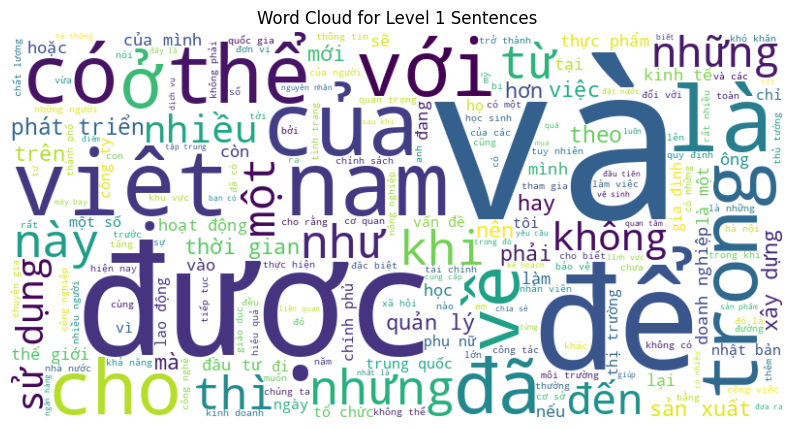

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Generate word cloud from given text data
def generate_word_cloud(text_data, title):
    # Join all text data into a single string
    text = " ".join(text_data)

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    # Display the word cloud
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title)
    plt.axis("off")
    plt.show()

# For df_lv1, concatenate sentences from sentence1 and sentence2
lv1_text = df_lv1['sentence1'].tolist() + df_lv1['sentence2'].tolist()

# Generate and display the word cloud for df_lv1
generate_word_cloud(lv1_text, "Word Cloud for Level 1 Sentences")


Most of the words on the word cloud on the df_lv1 dataset are stopwords. Those include some clear-meaning stopwords such as "của" (of), "là" (be), "có thể" (can/can be), "và" (and) "với" (with), "để" (to), "trong" (in/within), "khi" (when), "nhưng" (but/however), and some unclear meaning stopwords which need other word(s) to accomodate to have specific meaning such as "được", "cho",  ...

The only significant appearance of word that is non-stopwords in this word cloud is "việt nam" (Viet nam) - our country name.

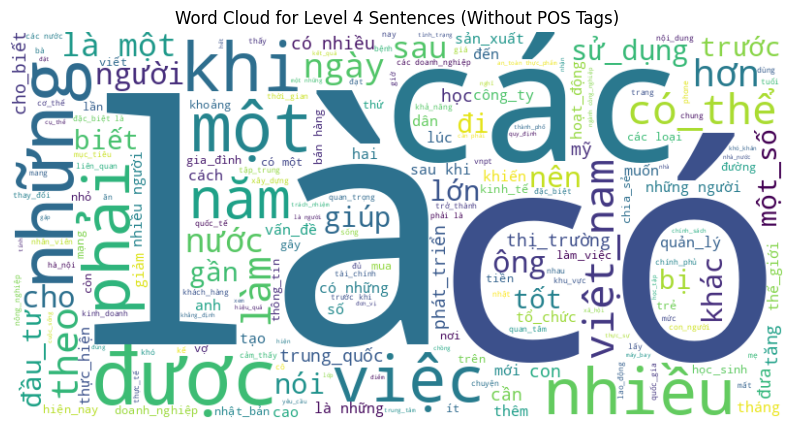

In [ ]:
# Remove parts of speech tags from words
def remove_pos_tags(text):
    # Remove all text after the last forward slash
    cleaned_text = re.sub(r'/\w+', '', text)
    return cleaned_text

# Generate word cloud from given text data
def generate_word_cloud(text_data, title):
    # Join all text data into a single string
    text = " ".join(text_data)

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    # Display the word cloud
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title)
    plt.axis("off")
    plt.show()

# For df_lv4, first remove parts of speech tags and then concatenate sentences from sentence1 and sentence2
df_lv4['cleaned_sentence1'] = df_lv4['sentence1'].apply(remove_pos_tags)
df_lv4['cleaned_sentence2'] = df_lv4['sentence2'].apply(remove_pos_tags)

# Concatenate the cleaned sentences into one list
lv4_cleaned_text = df_lv4['cleaned_sentence1'].tolist() + df_lv4['cleaned_sentence2'].tolist()

# Generate and display the word cloud for df_lv4
generate_word_cloud(lv4_cleaned_text, "Word Cloud for Level 4 Sentences (Without POS Tags)")

For the dataset with just four main POS (tags removed), there is also a prevalence of stopwords such as "là" (be), "các" (these/those/plural), "có" (have/be), những" (these/those/plural), "được" (be), "phải" (have to), "có_thể" (can), "năm" (year/five). Several tokenised words such as "phát_triển" (develop/development), "sử_dụng" (use/usage), "đầu_tư" (invest/investment), "việt_nam" appear on the list with the less prevalent.

The dominance of stopwords in the dataset may indicate the prevalence of stopwords in Vietnamese language usage. This would obscure the meaningful content, in other words, negatively impacting classifiers' performances.

## Histogram

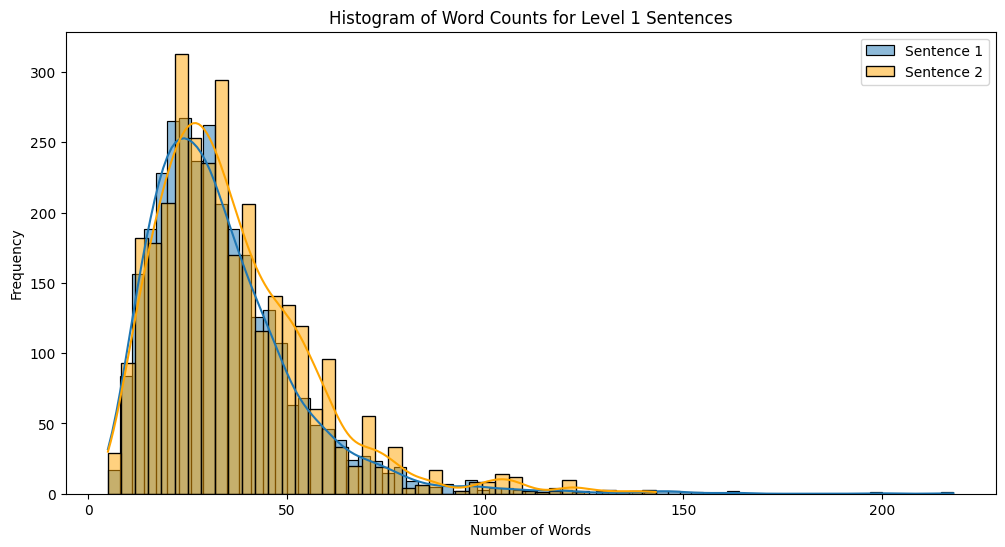

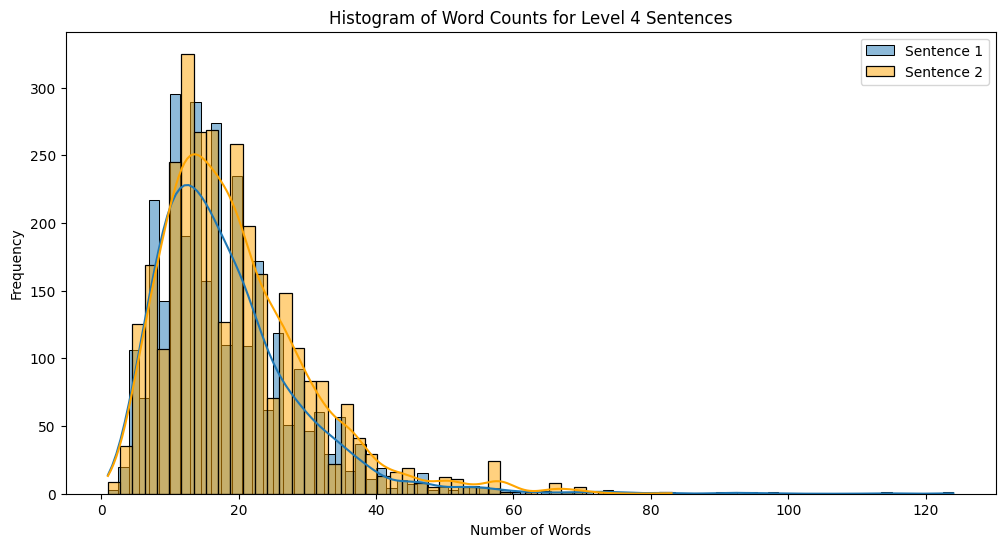

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Function to count the number of words in a sentence
def count_words(sentence):
    # Split the sentence into words and count them
    return len(sentence.split())

# Add word count columns to df_lv1
df_lv1['sentence1_word_count'] = df_lv1['sentence1'].apply(count_words)
df_lv1['sentence2_word_count'] = df_lv1['sentence2'].apply(count_words)

# Add word count columns to df_lv4
df_lv4['sentence1_word_count'] = df_lv4['cleaned_sentence1'].apply(count_words)
df_lv4['sentence2_word_count'] = df_lv4['cleaned_sentence2'].apply(count_words)

# Create histograms for df_lv1
plt.figure(figsize=(12, 6))
sns.histplot(df_lv1['sentence1_word_count'], kde=True, label='Sentence 1')
sns.histplot(df_lv1['sentence2_word_count'], kde=True, color='orange', label='Sentence 2')
plt.title("Histogram of Word Counts for Level 1 Sentences")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Create histograms for df_lv4
plt.figure(figsize=(12, 6))
sns.histplot(df_lv4['sentence1_word_count'], kde=True, label='Sentence 1')
sns.histplot(df_lv4['sentence2_word_count'], kde=True, color='orange', label='Sentence 2')
plt.title("Histogram of Word Counts for Level 4 Sentences")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.legend()
plt.show()


For the level 1 sentences, there is a left-skewed distribution. The most prevalent length is from 20 to 50 words. Sentences in "Sentence 2" tend to have a higher number of words when there is a word count in the sentence. There are outliers with more than 120 words per sentence.

There is a similar type of distribution in the level 4 sentences: left-skewed. The sentences after removing unneeded tags are shorter, with the main distribution from 8 to 30 words per sentence. The dataset still has outliers, with 80 to 120 words per sentence. The significant reduction of number of words in the level 4 compared to level 1 signifies the lost of information beneficial for classification.

Moreover, sentences 2 tend to have a higher number of words than sentences 1 for both datasets.

## Bar Chart - Pie Chart

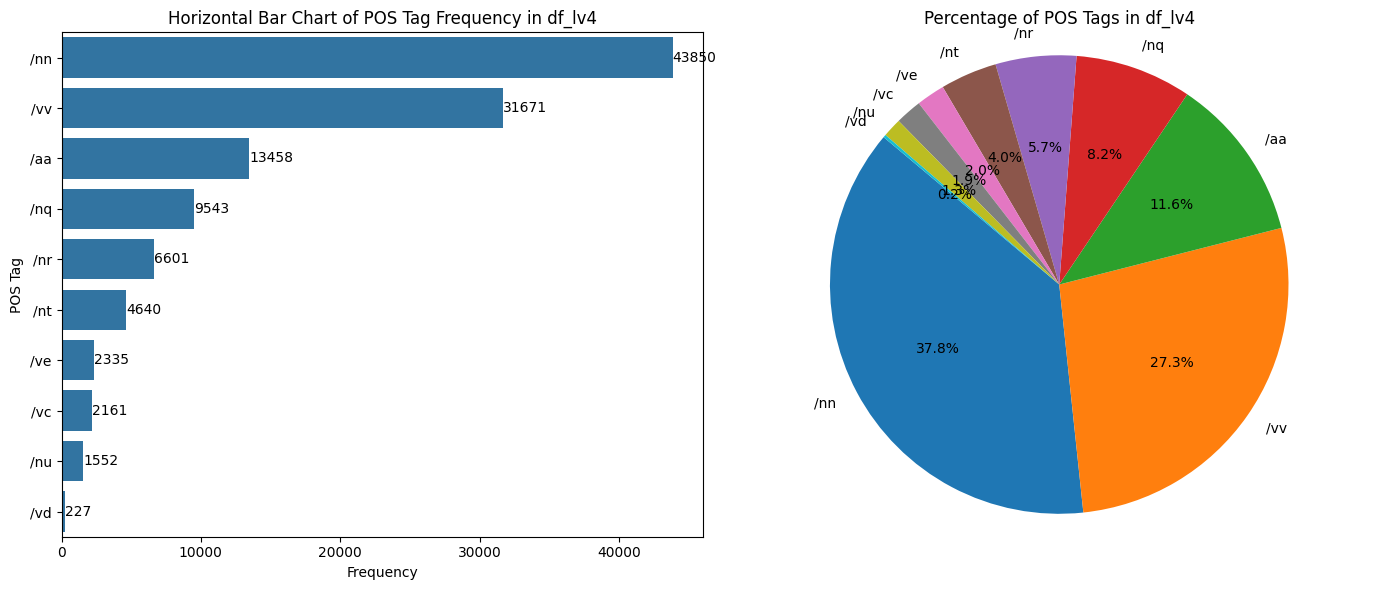

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Set of valid POS tags
valid_pos_tags = {'/nn', '/nu', '/nq', '/nt', '/nr', '/vd', '/vv', '/vc', '/ve', '/aa'}

# Function to extract valid POS tags from text
def extract_valid_pos_tags(text, valid_tags):
    # Find all POS tags and retain only valid ones
    all_tags = re.findall(r'/\w+', text)
    return [tag for tag in all_tags if tag in valid_tags]

# Extract valid POS tags from `df_lv4`
pos_tags = []

for sentence in df_lv4['sentence1']:
    pos_tags.extend(extract_valid_pos_tags(sentence, valid_pos_tags))

for sentence in df_lv4['sentence2']:
    pos_tags.extend(extract_valid_pos_tags(sentence, valid_pos_tags))

# Count the frequency of each POS tag
pos_tags_series = pd.Series(pos_tags)
pos_tags_count = pos_tags_series.value_counts()

# Plotting the bar chart
plt.figure(figsize=(14, 6))

# Plotting the horizontal bar chart
plt.subplot(1, 2, 1)
ax = sns.barplot(y=pos_tags_count.index, x=pos_tags_count.values, order=pos_tags_count.index, orient='h')
for i in range(len(pos_tags_count)):
    ax.text(pos_tags_count.values[i] + 1, i, str(pos_tags_count.values[i]), va='center')
plt.xlabel("Frequency")
plt.ylabel("POS Tag")
plt.title("Horizontal Bar Chart of POS Tag Frequency in df_lv4")

# Plotting the pie chart
plt.subplot(1, 2, 2)
plt.pie(pos_tags_count, labels=pos_tags_count.index, autopct='%1.1f%%', startangle=140)
plt.title("Percentage of POS Tags in df_lv4")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle

# Display both charts
plt.tight_layout()
plt.show()


As shown in both the bar chart and pie chart, noun tags are the most prevalent in the df_lv4, including tags for singular nouns (/nn-37.8%), classifiers for nouns (/nq-8.2%), proper nouns (/nr-5.7%), and temporal nouns (/nt-4%). Main verb tags (/vv) and adjective tags (/aa) are less prevalent, with 27.3% and 11.6%, respectively.

## Correlation HeatMap

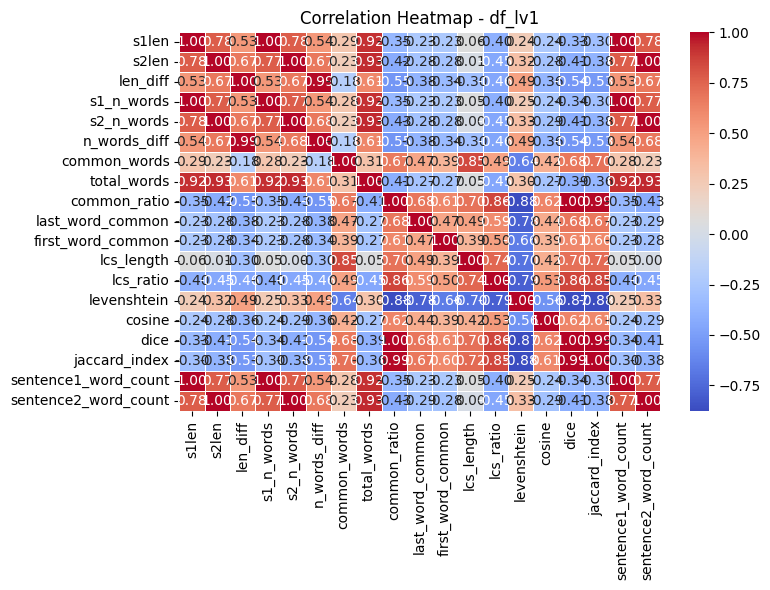

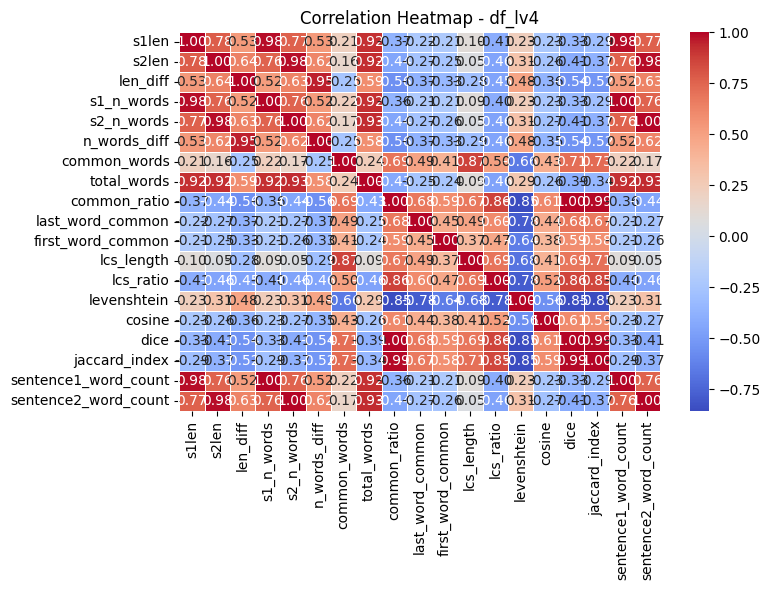

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_cols_lv1 = df_lv1.select_dtypes(include=['float64', 'int64'])
numeric_cols_lv4 = df_lv4.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrices
corr_lv1 = numeric_cols_lv1.corr()
corr_lv4 = numeric_cols_lv4.corr()

# Set up the matplotlib figure for df_lv1
plt.figure(figsize=(8, 6))
sns.heatmap(corr_lv1, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap - df_lv1')
plt.tight_layout()
plt.show()

# Set up the matplotlib figure for df_lv4
plt.figure(figsize=(8, 6))
sns.heatmap(corr_lv4, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap - df_lv4')
plt.tight_layout()
plt.show()


Several insights in df_lv1:


* The length of each sentence in each data frame is positively correlated (0.78).
* Each sentence’s length or number of words negatively correlates with the common ratio. For example, it is 0.35 and 0.42 for the length of sentence 1 and sentence 2 to the common ratio in df_lv1.
* It is reasonable when the first and last common words positively correlate with the common ratio, with 0.68 and 0.65, respectively.
* The LCS and Levenshtein ratios are no doubt positively and negatively correlated with the common ratio, with 0.86 and 0.88, respectively, since the LCS and Levenshtein ratios are measures of string similarity or dissimilarity between two strings.

The same pattern happens to df_lv2.

# Remove Stopwords

## Remove

In [ ]:
import requests
import pandas as pd

# Fetch the Vietnamese stopwords from the GitHub link
stopwords_url = "https://github.com/stopwords/vietnamese-stopwords/raw/master/vietnamese-stopwords.txt"
vietnamese_stopwords = set(requests.get(stopwords_url).text.split())

# Function to remove stopwords from text
def remove_stopwords(text):
    return " ".join([word for word in text.split() if word.lower() not in vietnamese_stopwords])

# Apply stopword removal to `df_lv1`
df_lv1['cleaned_sentence1'] = df_lv1['sentence1'].apply(remove_stopwords)
df_lv1['cleaned_sentence2'] = df_lv1['sentence2'].apply(remove_stopwords)

# Define a function to display comparisons
def show_comparison(df, n):
    for i in range(n):
        before_s1 = df.loc[i, 'sentence1']
        after_s1 = df.loc[i, 'cleaned_sentence1']
        before_s2 = df.loc[i, 'sentence2']
        after_s2 = df.loc[i, 'cleaned_sentence2']

        print(f"Example {i + 1} - Before:")
        print(f"Sentence 1: {before_s1}\nSentence 2: {before_s2}")

        print(f"Example {i + 1} - After:")
        print(f"Cleaned Sentence 1: {after_s1}\nCleaned Sentence 2: {after_s2}\n")

# Show comparisons for `df_lv1`
print("Comparisons for df_lv1:")
show_comparison(df_lv1, 2)  # Display the first two examples



Comparisons for df_lv1:
Example 1 - Before:
Sentence 1: về nguyên nhân thất bại của u23 việt nam đã được tìm ra cầu thủ mất phong độ thi đấu chọn sai điểm rơi phong độ nhiều cầu thủ trụ cột bị chấn thương lịch thi đấu thiếu khoa học thiếu hiểu biết về đối thủ có sai lầm về chiến thuật bản lĩnh thi đấu yếu kém 
Sentence 2: bản thân tổng giám đốc slna nguyễn hồng thanh đã phải kêu gọi vff có trách nhiệm báo cáo bộ văn hóa thể thao và du lịch chính phủ để tìm ra hướng giải cứu bóng đá việt nam 
Example 1 - After:
Cleaned Sentence 1: nguyên thất bại u23 việt nam thủ phong độ đấu sai rơi phong độ thủ trụ cột chấn lịch đấu khoa học thủ sai lầm chiến thuật lĩnh đấu yếu kém
Cleaned Sentence 2: tổng giám đốc slna nguyễn hồng kêu gọi vff trách nhiệm báo cáo văn hóa thao du lịch phủ hướng giải cứu bóng đá việt nam

Example 2 - Before:
Sentence 1: song có thể nói ngay rằng cuộc mổ xẻ tìm nguyên nhân thất bại của bóng đá chuyên nghiệp việt nam chưa đi đến nơi đến chốn 
Sentence 2: cả nền bóng đá vi

## Word cloud

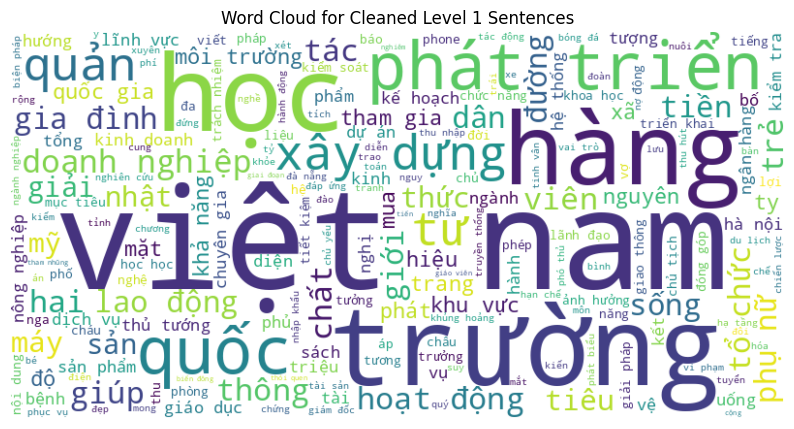

In [ ]:
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Function to remove parts of speech tags
def remove_pos_tags(text):
    # Remove everything after a forward slash, typically used for POS tags
    return re.sub(r'/\w+', '', text)

# Function to generate a word cloud
def generate_word_cloud(text_data, title):
    text = " ".join(text_data)  # Combine all text into a single string
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title)
    plt.axis("off")
    plt.show()

# Generate the word cloud for `df_lv1`
lv1_cleaned_text = df_lv1['cleaned_sentence1'].tolist() + df_lv1['cleaned_sentence2'].tolist()
generate_word_cloud(lv1_cleaned_text, "Word Cloud for Cleaned Level 1 Sentences")


After removing stopwords and tags, the dataframe has more meaningful words compared to the initial one. The most prevalent words now are "việt nam" (Vietnam), "trường" (school), "học" (study), "hàng" (goods/numbers), "xây dựng" (build), "doanh nghiệp" (enterprise) ...

In [ ]:
# Double check dataframe attributes before running ML models
df_lv1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3083 entries, 0 to 3082
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sentence1             3083 non-null   object 
 1   sentence2             3083 non-null   object 
 2   label                 3083 non-null   object 
 3   s1len                 3083 non-null   int64  
 4   s2len                 3083 non-null   int64  
 5   len_diff              3083 non-null   int64  
 6   s1_n_words            3083 non-null   int64  
 7   s2_n_words            3083 non-null   int64  
 8   n_words_diff          3083 non-null   int64  
 9   common_words          3083 non-null   float64
 10  total_words           3083 non-null   float64
 11  common_ratio          3083 non-null   float64
 12  last_word_common      3083 non-null   float64
 13  first_word_common     3083 non-null   float64
 14  lcs_length            3083 non-null   int64  
 15  lcs_ratio            

In [ ]:
df_lv4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3083 entries, 0 to 3082
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sentence1             3083 non-null   object 
 1   sentence2             3083 non-null   object 
 2   label                 3083 non-null   object 
 3   s1len                 3083 non-null   int64  
 4   s2len                 3083 non-null   int64  
 5   len_diff              3083 non-null   int64  
 6   s1_n_words            3083 non-null   int64  
 7   s2_n_words            3083 non-null   int64  
 8   n_words_diff          3083 non-null   int64  
 9   common_words          3083 non-null   float64
 10  total_words           3083 non-null   float64
 11  common_ratio          3083 non-null   float64
 12  last_word_common      3083 non-null   float64
 13  first_word_common     3083 non-null   float64
 14  lcs_length            3083 non-null   int64  
 15  lcs_ratio            

# **Model Implementation**

## Train-Test Split

Shuffle both levels

In [ ]:
df_lv1 = df_lv1.sample(frac=1).reset_index(drop=True)
df_lv4 = df_lv4.sample(frac=1).reset_index(drop=True)

In [ ]:
df_lv1['label'] = df_lv1['label'].astype(int)
df_lv4['label'] = df_lv4['label'].astype(int)

### Level 1 Train-Test Split

In [ ]:
cutoff = round(len(df_lv1)*0.75)

df_train = df_lv1[:cutoff]
df_test = df_lv1[cutoff:].reset_index(drop=True)

print('Number of pairs for training: {}'.format(len(df_train)))
print('Number of pairs for testing: {}'.format(len(df_test)))

Number of pairs for training: 2312
Number of pairs for testing: 771


In [ ]:
df_train['label'].value_counts()

label
1    1182
0    1130
Name: count, dtype: int64

Remove attributes with type = "object" or convert them into numeric format.

In [ ]:
# Drop specified columns from the DataFrames
columns_to_drop = ["sentence1", "sentence2", "label", "embedding 1", "embedding 2", "sentence1_word_count", "sentence2_word_count", "cleaned_sentence1", "cleaned_sentence2"]
x_train = df_train.drop(columns=columns_to_drop)
x_test = df_test.drop(columns=columns_to_drop)

# Convert only columns associated with "cluster 1" and "cluster 2" from object to int
to_number = ["cluster 1", "cluster 2"]
x_train[to_number] = x_train[to_number].astype(int)
x_test[to_number] = x_test[to_number].astype(int)

# Extract labels
y_train = df_train['label'].values
y_test = df_test['label'].values

### Level 4 Train-Test Split

In [ ]:
cutoff = round(len(df_lv4)*0.75)

df_train_4 = df_lv4[:cutoff]
df_test_4 = df_lv4[cutoff:].reset_index(drop=True)

print('Number of pairs for training: {}'.format(len(df_train_4)))
print('Number of pairs for testing: {}'.format(len(df_test_4)))

Number of pairs for training: 2312
Number of pairs for testing: 771


In [ ]:
df_train_4['label'].value_counts()

label
1    1184
0    1128
Name: count, dtype: int64

In [ ]:
# Convert 'label' column from object to int
df_test_4['label'] = df_test['label'].astype(int)

# Drop specified columns from the DataFrames
x_train_4 = df_train_4.drop(columns=columns_to_drop)
x_test_4 = df_test_4.drop(columns=columns_to_drop)

# Convert only columns associated with "cluster 1" and "cluster 2" from object to int
x_train_4[to_number] = x_train_4[to_number].astype(int)
x_test_4[to_number] = x_test_4[to_number].astype(int)

# Extract labels
y_train_4 = df_train_4['label'].values
y_test_4 = df_test_4['label'].values

## Random Forest Classifier

### Level 1 RFC

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint

# Define the parameter grid for the random search
param_dist = {
    'n_estimators': [10, 50, 100, 200, 500],
    'max_features': ['sqrt', 'log2'],
    'max_depth': np.arange(5, 16),
    'min_samples_split': np.arange(2, 11),
    'min_samples_leaf': np.arange(2, 11),
}

# Create a Random Forest classifier
rfc = RandomForestClassifier(random_state=42)

# Create a RandomizedSearchCV object with a GridSearchCV object as the estimator
# This will search over a random subset of the hyperparameter space using k-fold cross-validation
grid_search = RandomizedSearchCV(estimator = rfc, param_distributions = param_dist, cv = 10, verbose=2, n_jobs = -1)

# Fit the randomized search to the data
grid_search.fit(x_train, y_train)

Fitting 10 folds for each of 10 candidates, totalling 100 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning:

os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.

/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning:

os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.



RandomizedSearchCV(cv=10, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10]),
                                        'min_samples_split': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10]),
                                        'n_estimators': [10, 50, 100, 200,
                                                         500]},
                   verbose=2)

In [ ]:
# Get the best parameters
best_params = grid_search.best_params_
best_estimator = grid_search.best_estimator_

# Fit the best model to your training data
best_estimator.fit(x_train, y_train)

print("Best Parameters:", best_params)
print(best_estimator)
print("Best Accuracy:", grid_search.best_score_)

Best Parameters: {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'max_depth': 5}
RandomForestClassifier(max_depth=5, max_features='log2', min_samples_leaf=3,
                       min_samples_split=10, n_estimators=50, random_state=42)
Best Accuracy: 0.976211001642036


In [ ]:
# Calculate the predicted probabilities for class 1 (positive class)
y_prob = grid_search.predict_proba(x_test)[:,1]

# Create columns for probability and predicted class in the DataFrame
df_test['prob_RFC'] = y_prob
df_test['is_duplicate_RFC'] = 0  # Initialize with default value

# Set a condition using the 'prob_RFC' column
condition = df_test['prob_RFC'] >= 0.5

# Use numpy.where to set the 'is_duplicate_RFC' column based on the condition
df_test['is_duplicate_RFC'] = np.where(condition, 1, df_test['is_duplicate_RFC'])

# Convert the 'is_duplicate_RFC' column to integer type
df_test['is_duplicate_RFC'] = df_test['is_duplicate_RFC'].astype(int)

# Print the updated DataFrame
df_test.head()

,sentence1,sentence2,label,s1len,s2len,len_diff,s1_n_words,s2_n_words,n_words_diff,common_words,...,cluster 1,cluster 2,dice,jaccard_index,sentence1_word_count,sentence2_word_count,cleaned_sentence1,cleaned_sentence2,prob_RFC,is_duplicate_RFC
0,trong khi đó thị trường việt nam chỉ cung cấp ...,vào thời điểm này starbucks new world cửa hàng...,0,191,101,90,43,22,21,6.0,...,10,3,0.163934,0.089286,42,21,trường việt nam cung 3 tổng sản hạt cà phê ara...,starbucks new world cửa hàng việt nam hot,0.012192,0
1,chúng tôi từng lặng người trước những bức thư ...,chúng tôi từng vô cùng xúc động trước những lá...,1,228,236,8,50,52,2,40.0,...,8,8,0.886364,0.795918,49,51,lặng thư viết hồn chuộng hòa bình thư chủ tịch...,xúc động lá thư viết chân chuộng hòa bình thư ...,0.997584,1
2,bằng cách gia nhập một mạng cơ hội gặp những n...,cô bạn tôi còn gặp một trường hợp éo le hơn kh...,0,165,111,54,38,27,11,9.0,...,13,6,0.285714,0.166667,37,26,gia nhập rệt,trường éo đăng face,0.011717,0
3,trong thời đại kinh tế khó khăn một số lượng l...,trong bối cảnh kinh tế khó khăn nhiều doanh ng...,1,233,230,3,50,49,1,35.0,...,4,4,0.800000,0.666667,49,48,kinh doanh nghiệp làng cntt hoạt động kinh doa...,bối cảnh kinh doanh nghiệp làng cntt chủ yếu h...,0.997846,1
4,gia công được hiểu chỉ là bán mồ hôi với giá r...,thứ nhất công nghệ cao là hướng đi duy nhất để...,0,186,172,14,44,41,3,8.0,...,10,10,0.202899,0.112903,43,40,gia mồ hôi rẻ đoạn gia đoạn gia chuỗi chấm dứt,nghệ hướng nâng gia nông sản hàng hóa động phá...,0.010546,0


In [ ]:
from sklearn.metrics import classification_report
# Classification report
report_lv1_rf = classification_report(y_test, condition)
print("Classification report for df_lv1:\n", report_lv1_rf)

Classification report for df_lv1:
               precision    recall  f1-score   support

           0       0.98      0.97      0.97       376
           1       0.97      0.98      0.97       395

    accuracy                           0.97       771
   macro avg       0.97      0.97      0.97       771
weighted avg       0.97      0.97      0.97       771



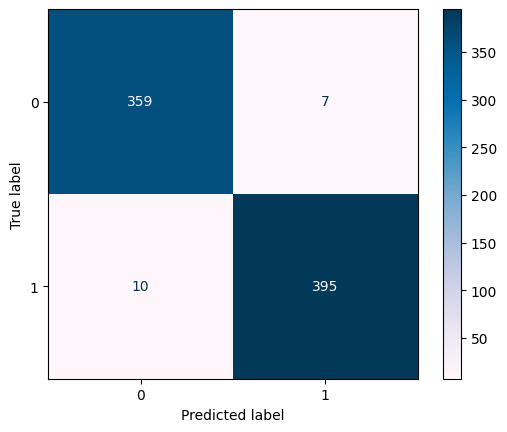

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

mat = confusion_matrix(y_test, df_test['is_duplicate_RFC'])
disp = ConfusionMatrixDisplay(confusion_matrix=mat)
disp.plot(cmap=plt.cm.PuBu)
plt.show()

The AUC is 0.993


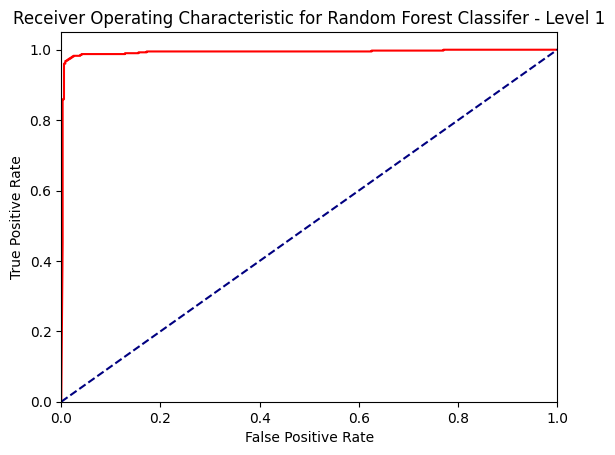

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted")
print('The AUC is %.3f' % auc)

plt.figure()
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, color='red')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # The dashed line for random choice
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Random Forest Classifer - Level 1')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss

print("Random Forest Classifier Prediction on Level 1 Dataset")
print("Accuracy score =", accuracy_score(df_test['label'], df_test['is_duplicate_RFC']))
print("Log loss score =", log_loss(df_test['label'], df_test['prob_RFC']))

Random Forest Classifier Prediction on Level 1 Dataset
Accuracy score = 0.9779507133592736
Log loss score = 0.11766389844262667


<ipython-input-128-b13f9f808c1a>:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




Text(0.5, 1.0, 'Visualizing Feature Importances')

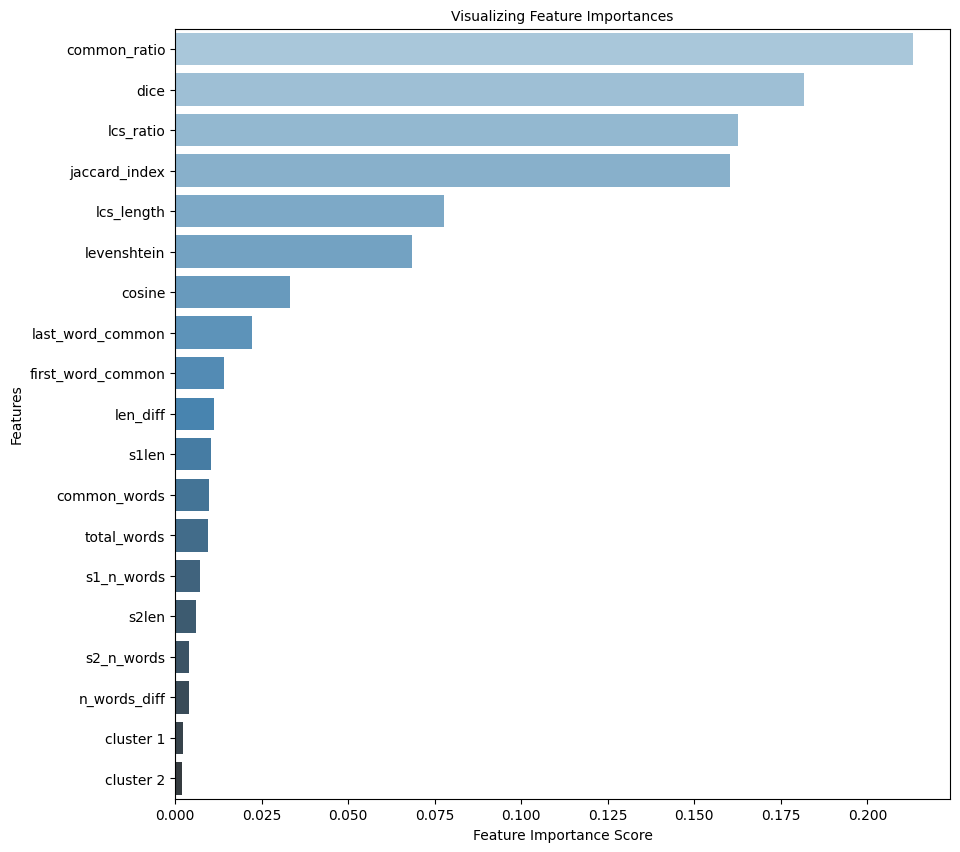

In [ ]:
feature_imp = pd.Series(best_estimator.feature_importances_,
                        index=x_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x=feature_imp, y=feature_imp.index, palette=("Blues_d"))
plt.xlabel('Feature Importance Score', fontsize=10)
plt.ylabel('Features', fontsize=10)
plt.title("Visualizing Feature Importances", fontsize=10)

### Level 4 RFC

In [ ]:
# Create a Random Forest classifier
rfc_4 = RandomForestClassifier(random_state=42)

# Create a RandomizedSearchCV object with a GridSearchCV object as the estimator
# This will search over a random subset of the hyperparameter space using k-fold cross-validation
grid_search = RandomizedSearchCV(estimator = rfc_4, param_distributions = param_dist, cv = 10, verbose=2, n_jobs = -1)

# Fit the randomized search to the data
grid_search.fit(x_train_4, y_train_4)

Fitting 10 folds for each of 10 candidates, totalling 100 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning:

os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.



RandomizedSearchCV(cv=10, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10]),
                                        'min_samples_split': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10]),
                                        'n_estimators': [10, 50, 100, 200,
                                                         500]},
                   verbose=2)

In [ ]:
# Get the best parameters
best_params_4 = grid_search.best_params_
best_estimator_4 = grid_search.best_estimator_

# Fit the best model to your training data
best_estimator.fit(x_train_4, y_train_4)

print("Best Parameters:", best_params_4)
print(best_estimator_4)
print("Best Accuracy:", grid_search.best_score_)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': 14}
RandomForestClassifier(max_depth=14, min_samples_leaf=3, min_samples_split=8,
                       n_estimators=200, random_state=42)
Best Accuracy: 0.970588893864756


In [ ]:
# Calculate the predicted probabilities for class 1 (positive class)
y_prob_4 = best_estimator.predict_proba(x_test_4)[:, 1]

# Create columns for probability and predicted class in the DataFrame
df_test_4['prob_RFC_4'] = y_prob_4
df_test_4['is_duplicated_4'] = 0  # Initialize with default value

# Set a condition using the 'prob_RFC_4' column
condition = df_test_4['prob_RFC_4'] >= 0.5

# Use numpy.where to set the 'is_duplicated_4' column based on the condition
df_test_4['is_duplicated_4'] = np.where(condition, 1, df_test_4['is_duplicated_4'])

# Convert the 'is_duplicated_4' column to integer type
df_test_4['is_duplicated_4'] = df_test_4['is_duplicated_4'].astype(int)

# Print the updated DataFrame
df_test_4.head()

,sentence1,sentence2,label,s1len,s2len,len_diff,s1_n_words,s2_n_words,n_words_diff,common_words,...,cluster 1,cluster 2,dice,jaccard_index,cleaned_sentence1,cleaned_sentence2,sentence1_word_count,sentence2_word_count,prob_RFC_4,is_duplicated_4
0,sau/nn khi/nt lập/vv xong/aa danh_sách/nn tập/...,chọn/vv cách/nn chỉnh_sửa/vv danh_sách/nn việc...,0,162,229,67,18,25,7,5.0,...,14,14,0.210526,0.117647,sau khi lập xong danh_sách tập loại_bỏ thói_qu...,chọn cách chỉnh_sửa danh_sách việc sắp_xếp các...,17,24,0.010615,0
1,chủ_quyền/nq biển/nn đảo/nn tổ_quốc/nn là/vc t...,trước/nn tình_hình/nn trên/nn nhiệm_vụ/nn xây_...,1,260,294,34,29,28,1,7.0,...,3,11,0.250000,0.142857,chủ_quyền biển đảo tổ_quốc là thiêng_liêng là ...,trước tình_hình trên nhiệm_vụ xây_dựng hqndvn ...,28,27,0.012539,0
2,khi/nt giá/nn dầu/nn malaysia/nr là/vc 0/nq 57...,khi/nt dầu/nn malaysia/nr được/vv bán/vv giá/n...,0,168,177,9,24,25,1,18.0,...,9,9,0.918919,0.850000,khi giá dầu malaysia là 0 57 usd bằng 25 % giá...,khi dầu malaysia được bán giá 0 57 usd bằng 25...,23,24,0.995149,1
3,nhiều/aa tiết/nn học/vv sử/nr sinh_động/aa đượ...,nhiều/aa tiết/nn học/vv sử/nr sinh_động/aa hìn...,1,88,67,21,10,8,2,8.0,...,7,7,0.875000,0.777778,nhiều tiết học sử sinh_động được lồng_ghép hìn...,nhiều tiết học sử sinh_động hình_ảnh minh_hoạ,9,7,0.998546,1
4,nhật_bản/nr cấp/nn tàu/nn tuần_tra/vv việt_nam...,nhật_bản/nr cung_cấp/vv các/nq tàu/nn tuần_tra...,0,162,189,27,17,19,2,14.0,...,0,0,0.812500,0.684211,nhật_bản cấp tàu tuần_tra việt_nam đầu năm sau...,nhật_bản cung_cấp các tàu tuần_tra kiểm_ngư vi...,16,18,0.998053,1


In [ ]:
from sklearn.metrics import classification_report

# Classification report
report_lv4_rf = classification_report(y_test, condition)
print("Classification report for df_lv4:\n", report_lv4_rf)

Classification report for df_lv4:
               precision    recall  f1-score   support

           0       0.52      0.52      0.52       376
           1       0.54      0.53      0.54       395

    accuracy                           0.53       771
   macro avg       0.53      0.53      0.53       771
weighted avg       0.53      0.53      0.53       771



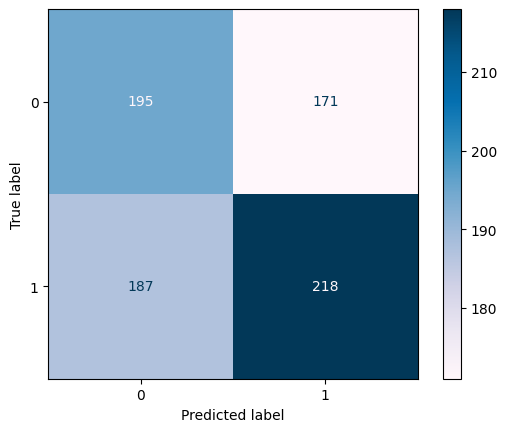

In [ ]:
mat = confusion_matrix(y_test_4, df_test_4['is_duplicated_4'])
disp = ConfusionMatrixDisplay(confusion_matrix=mat)
disp.plot(cmap=plt.cm.PuBu)
plt.show()

The AUC is 0.530


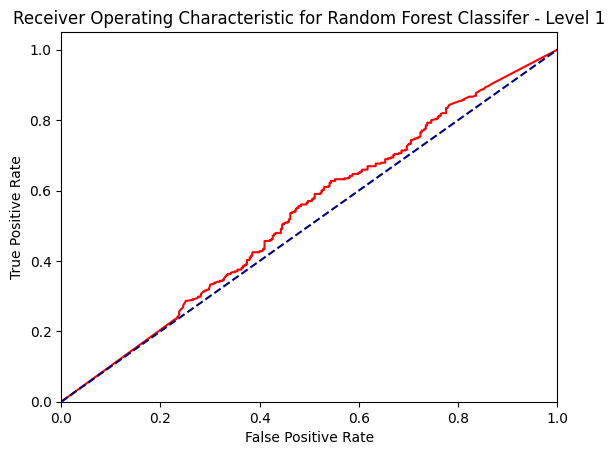

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
auc = roc_auc_score(y_test_4, y_prob_4, multi_class="ovr", average="weighted")
print('The AUC is %.3f' % auc)

plt.figure()
fpr, tpr, thresholds = roc_curve(y_test_4, y_prob_4)
plt.plot(fpr, tpr, color='red')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # The dashed line for random choice
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Random Forest Classifer - Level 1')
plt.show()

In [ ]:
print("Random Forest Classifier Prediction on Level 1 Dataset")
print("Accuracy score =", accuracy_score(df_test_4['label'], df_test_4['is_duplicated_4']))
print("Log loss score =", log_loss(df_test_4['label'], df_test_4['prob_RFC_4']))

Random Forest Classifier Prediction on Level 1 Dataset
Accuracy score = 0.5356679636835279
Log loss score = 7.072028545918979


## Convolutional Neural Networks

In [ ]:
pip install pydot graphviz

### Level 1 CNN

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 17, 128)           512       
                                                                 
 max_pooling1d (MaxPooling1  (None, 8, 128)            0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 6, 128)            49280     
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 3, 128)            0         
 g1D)                                                            
                                                                 
 flatten (Flatten)           (None, 384)               0         
                                                                 
 dense (Dense)               (None, 256)               9

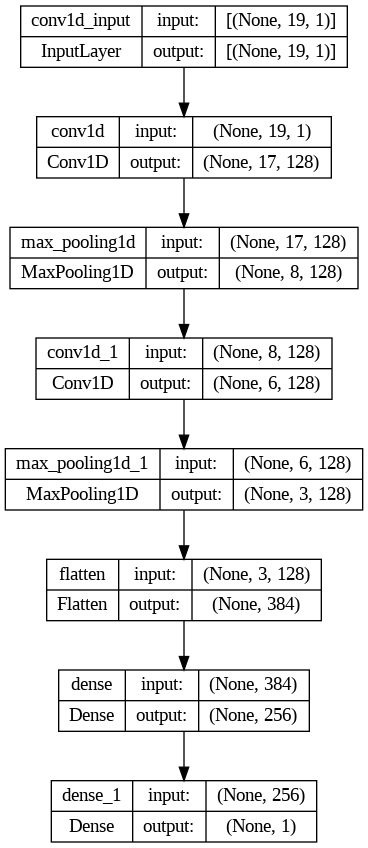

In [ ]:
from tensorflow.keras.utils import plot_model
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

# Define the CNN model architecture
model = Sequential()
model.add(Conv1D(128, 3, activation='relu', input_shape=(x_train.shape[1], 1)))
model.add(MaxPooling1D(2))
model.add(Conv1D(128, 3, activation='relu'))
model.add(MaxPooling1D(2))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Binary classification, so use sigmoid activation
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# Print model summary
model.summary()

# Plot the model architecture
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [ ]:
# Convert target labels from strings to float
y_train = y_train.astype(float)
y_test = y_test.astype(float)

In [ ]:
# Train the model
history = model.fit(x_train, y_train, epochs=50, batch_size=300, validation_data=(x_test, y_test))

Epoch 1/50
8/8 [==============================] - 3s 128ms/step - loss: 1.6181 - accuracy: 0.7253 - val_loss: 0.3357 - val_accuracy: 0.9105
Epoch 2/50
8/8 [==============================] - 1s 70ms/step - loss: 0.2893 - accuracy: 0.9420 - val_loss: 0.3270 - val_accuracy: 0.9274
Epoch 3/50
8/8 [==============================] - 1s 65ms/step - loss: 0.2370 - accuracy: 0.9602 - val_loss: 0.2051 - val_accuracy: 0.9559
Epoch 4/50
8/8 [==============================] - 1s 68ms/step - loss: 0.2140 - accuracy: 0.9624 - val_loss: 0.1753 - val_accuracy: 0.9598
Epoch 5/50
8/8 [==============================] - 1s 66ms/step - loss: 0.1632 - accuracy: 0.9658 - val_loss: 0.1441 - val_accuracy: 0.9624
Epoch 6/50
8/8 [==============================] - 1s 69ms/step - loss: 0.1407 - accuracy: 0.9676 - val_loss: 0.1332 - val_accuracy: 0.9650
Epoch 7/50
8/8 [==============================] - 0s 39ms/step - loss: 0.1351 - accuracy: 0.9676 - val_loss: 0.1325 - val_accuracy: 0.9637
Epoch 8/50
8/8 [==========

In [ ]:
# Final evaluation of the model
scores = model.evaluate(x_test, y_test, verbose=1)
print("Accuracy: %.2f%%" % (scores[1]*100))

25/25 [==============================] - 0s 3ms/step - loss: 0.0922 - accuracy: 0.9702
Accuracy: 97.02%


25/25 [==============================] - 0s 5ms/step


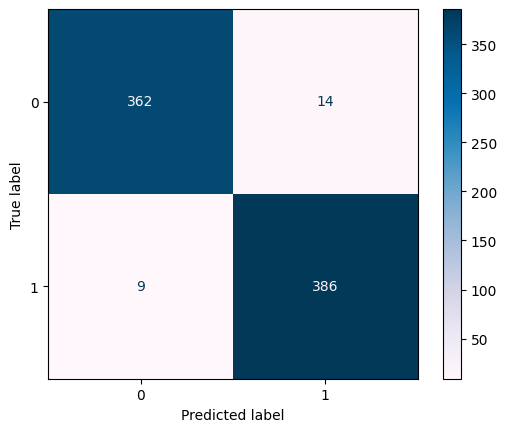

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Generate predictions
y_pred_cnn1 = (model.predict(x_test) > 0.5).astype("int32")

mat = confusion_matrix(y_test, y_pred_cnn1)
disp = ConfusionMatrixDisplay(confusion_matrix=mat)
disp.plot(cmap=plt.cm.PuBu)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Classification report
report_lv1_cnn = classification_report(y_test, y_pred_cnn1)
print("Classification report for df_lv1:\n", report_lv1_cnn)

Classification report for df_lv1:
               precision    recall  f1-score   support

         0.0       0.98      0.96      0.97       376
         1.0       0.96      0.98      0.97       395

    accuracy                           0.97       771
   macro avg       0.97      0.97      0.97       771
weighted avg       0.97      0.97      0.97       771



The AUC is 0.981


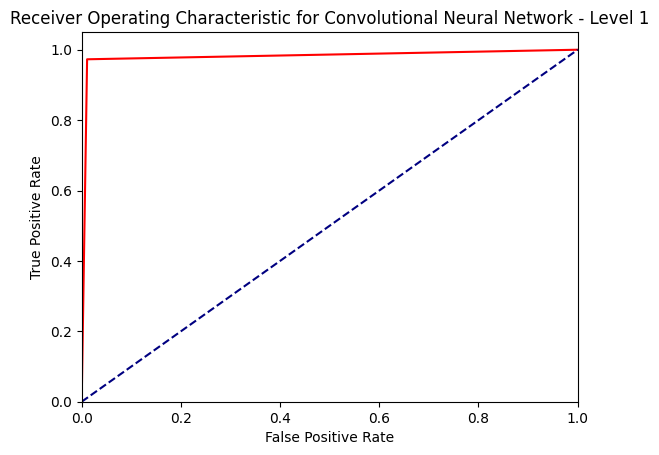

In [ ]:
auc = roc_auc_score(y_test, y_pred_cnn1, multi_class="ovr", average="weighted")
print('The AUC is %.3f' % auc)

plt.figure()
fpr, tpr, thresholds = roc_curve(y_test, y_pred_cnn1)
plt.plot(fpr, tpr, color='red')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # The dashed line for random choice
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Convolutional Neural Network - Level 1')
plt.show()

In [ ]:
# Calculate the predicted probabilities for class 1 (positive class)
y_prob_cnn1 = model.predict(x_test)

25/25 [==============================] - 0s 6ms/step


In [ ]:
# Create columns for probability and predicted class in the DataFrame
df_test['prob_CNN'] = y_prob_cnn1
df_test['is_duplicate_CNN'] = 0  # Initialize with default value

# Set a condition using the 'prob_CNN' column
condition = df_test['prob_CNN'] >= 0.5

# Use numpy.where to set the 'is_duplicate_CNN' column based on the condition
df_test['is_duplicate_CNN'] = np.where(condition, 1, df_test['is_duplicate_CNN'])

# Convert the 'is_duplicate_CNN' column to integer type
df_test['is_duplicate_CNN'] = df_test['is_duplicate_CNN'].astype(int)

# Print the updated DataFrame
df_test.head()

,sentence1,sentence2,label,s1len,s2len,len_diff,s1_n_words,s2_n_words,n_words_diff,common_words,...,dice,jaccard_index,sentence1_word_count,sentence2_word_count,cleaned_sentence1,cleaned_sentence2,prob_RFC,is_duplicate_RFC,prob_CNN,is_duplicate_CNN
0,chúng tôi phân công anh chị dạy em nhỏ hơn và ...,chúng tôi giao việc cho anh chị dạy em nhỏ hơn...,1,84,102,18,20,24,4,18.0,...,0.871795,0.772727,19,23,phân dạy giúp vặt hàng,giao dạy giúp đỡ vặt hàng,1.000000,1,9.976810e-01,1
1,một chuyên gia tư vấn tài chính có thâm niên ở...,một chuyên gia tư vấn tài chính có thâm niên ở...,1,235,237,2,57,57,0,45.0,...,0.880000,0.785714,56,56,chuyên gia tư tài thâm niên tp hcm nhượng phiế...,chuyên gia tư tài thâm niên tp hcm tiết lộ như...,0.993766,1,9.999900e-01,1
2,dương vân nga hoàng hậu của hai vua lý chiêu h...,người phụ nữ ngoài việc chu tất công việc gia ...,0,491,279,212,106,62,44,11.0,...,0.149254,0.080645,105,61,dương vân nga hoàng hai vua chiêu hoàng nhường...,phụ nữ gia đình thông khéo léo động viên chồng...,0.000755,0,4.612422e-08,0
3,hnxindex tăng 03 điểm 037 lên 811 điểm,sàn hà nội hnxindex tăng 03 điểm lên 811 điểm,1,39,46,7,9,11,2,7.0,...,0.750000,0.600000,8,10,hnxindex 03 037 811,sàn hà nội hnxindex 03 811,1.000000,1,9.056743e-01,1
4,hai đại gia sản xuất ôtô general motors gm và ...,lehman brather ngân hàng đầu tư đứng hàng thứ ...,0,100,170,70,23,41,18,9.0,...,0.271186,0.156863,22,40,hai gia sản ôtô general motors gm chrysler nộp...,lehman brather ngân hàng tư đứng hàng tư phố w...,0.119181,0,1.779980e-02,0


### Level 4 CNN

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 17, 128)           512       
                                                                 
 max_pooling1d_2 (MaxPoolin  (None, 8, 128)            0         
 g1D)                                                            
                                                                 
 conv1d_3 (Conv1D)           (None, 6, 128)            49280     
                                                                 
 max_pooling1d_3 (MaxPoolin  (None, 3, 128)            0         
 g1D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 384)               0         
                                                                 
 dense_2 (Dense)             (None, 256)              

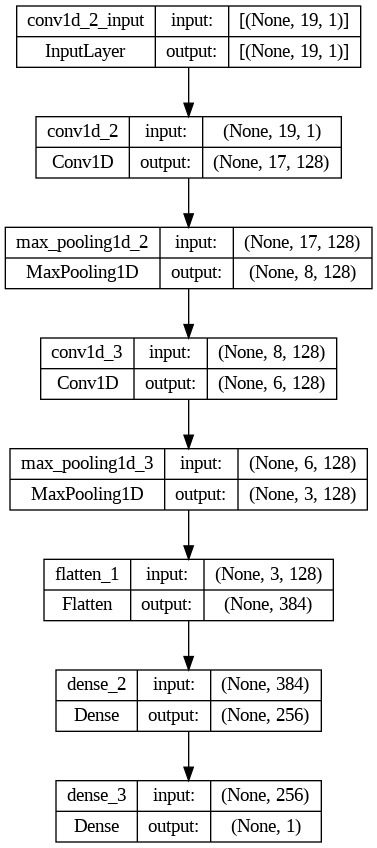

In [ ]:
# Define the CNN model architecture
model4 = Sequential()
model4.add(Conv1D(128, 3, activation='relu', input_shape=(x_train_4.shape[1], 1)))
model4.add(MaxPooling1D(2))
model4.add(Conv1D(128, 3, activation='relu'))
model4.add(MaxPooling1D(2))
model4.add(Flatten())
model4.add(Dense(256, activation='relu'))
model4.add(Dense(1, activation='sigmoid'))  # Binary classification, so use sigmoid activation
model4.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# Print model summary
model4.summary()

# Plot the model architecture
plot_model(model4, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [ ]:
# Train the model
history = model4.fit(x_train_4, y_train_4, epochs=50, batch_size=300, validation_data=(x_test_4, y_test_4))

Epoch 1/50
8/8 [==============================] - 5s 157ms/step - loss: 0.9803 - accuracy: 0.7535 - val_loss: 5.1618 - val_accuracy: 0.5045
Epoch 2/50
8/8 [==============================] - 1s 116ms/step - loss: 0.2539 - accuracy: 0.9451 - val_loss: 5.4758 - val_accuracy: 0.5266
Epoch 3/50
8/8 [==============================] - 1s 109ms/step - loss: 0.2540 - accuracy: 0.9459 - val_loss: 4.3741 - val_accuracy: 0.5123
Epoch 4/50
8/8 [==============================] - 0s 42ms/step - loss: 0.1991 - accuracy: 0.9507 - val_loss: 3.4695 - val_accuracy: 0.5253
Epoch 5/50
8/8 [==============================] - 0s 36ms/step - loss: 0.1758 - accuracy: 0.9533 - val_loss: 2.5812 - val_accuracy: 0.5201
Epoch 6/50
8/8 [==============================] - 0s 34ms/step - loss: 0.1621 - accuracy: 0.9567 - val_loss: 2.6927 - val_accuracy: 0.5214
Epoch 7/50
8/8 [==============================] - 0s 34ms/step - loss: 0.1618 - accuracy: 0.9559 - val_loss: 2.4599 - val_accuracy: 0.5240
Epoch 8/50
8/8 [========

In [ ]:
# Final evaluation of the model
scores = model.evaluate(x_test_4, y_test_4, verbose=1)
print("Accuracy: %.2f%%" % (scores[1]*100))

25/25 [==============================] - 0s 3ms/step - loss: 2.0918 - accuracy: 0.5162
Accuracy: 51.62%


25/25 [==============================] - 0s 3ms/step


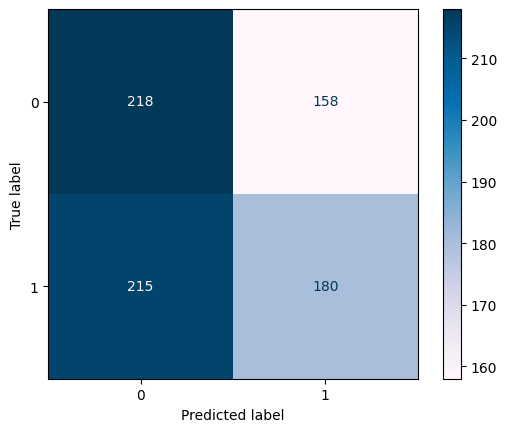

In [ ]:
# Generate predictions
y_pred_cnn4 = (model.predict(x_test_4) > 0.5).astype("int32")

mat = confusion_matrix(y_test_4, y_pred_cnn4)
disp = ConfusionMatrixDisplay(confusion_matrix=mat)
disp.plot(cmap=plt.cm.PuBu)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Classification report
report_lv4_cnn = classification_report(y_test, y_pred_cnn4)
print("Classification report for df_lv4:\n", report_lv4_cnn)

Classification report for df_lv4:
               precision    recall  f1-score   support

         0.0       0.50      0.58      0.54       376
         1.0       0.53      0.46      0.49       395

    accuracy                           0.52       771
   macro avg       0.52      0.52      0.52       771
weighted avg       0.52      0.52      0.51       771



The AUC is 0.537


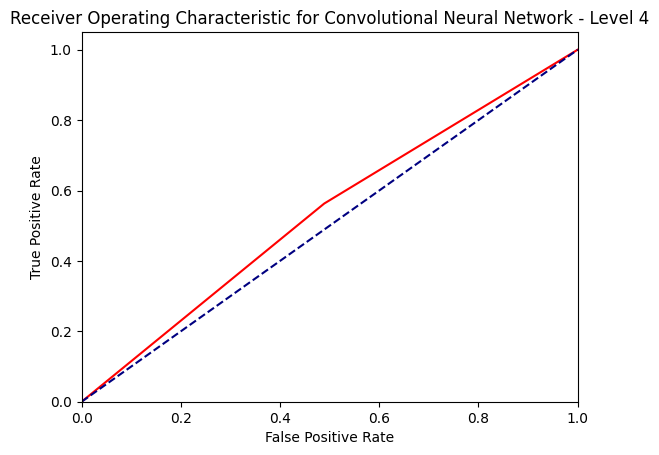

In [ ]:
auc = roc_auc_score(y_test_4, y_pred_cnn4, multi_class="ovr", average="weighted")
print('The AUC is %.3f' % auc)

plt.figure()
fpr, tpr, thresholds = roc_curve(y_test_4, y_pred_cnn4)
plt.plot(fpr, tpr, color='red')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # The dashed line for random choice
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Convolutional Neural Network - Level 4')
plt.show()

In [ ]:
# Calculate the predicted probabilities for class 1 (positive class)
y_prob_cnn4 = model.predict(x_test_4)

# Create columns for probability and predicted class in the DataFrame
df_test_4['prob_CNN'] = y_prob_cnn4
df_test_4['is_duplicate_CNN'] = 0  # Initialize with default value

# Set a condition using the 'prob_CNN' column
condition = df_test_4['prob_CNN'] >= 0.5

# Use numpy.where to set the 'is_duplicate_CNN' column based on the condition
df_test_4['is_duplicate_CNN'] = np.where(condition, 1, df_test_4['is_duplicate_CNN'])

# Convert the 'is_duplicate_CNN' column to integer type
df_test_4['is_duplicate_CNN'] = df_test_4['is_duplicate_CNN'].astype(int)

# Print the updated DataFrame
df_test_4.head()

25/25 [==============================] - 0s 4ms/step


,sentence1,sentence2,label,s1len,s2len,len_diff,s1_n_words,s2_n_words,n_words_diff,common_words,...,dice,jaccard_index,cleaned_sentence1,cleaned_sentence2,sentence1_word_count,sentence2_word_count,prob_RFC_4,is_duplicated_4,prob_CNN,is_duplicate_CNN
0,những/nq nghiên_cứu/nn cho_thấy/vv các/nq em_b...,âm_nhạc/nn thông_minh/aa khi/nt nằm/vv bụng/nn...,1,293,218,75,34,26,8,7.0,...,0.222222,0.125000,những nghiên_cứu cho_thấy các em_bé được bú mẹ...,âm_nhạc thông_minh khi nằm bụng mẹ năm khi ra_...,33,25,0.005357,0,0.003875,0
1,các/nq nước/nn khác/aa khu_vực/nn philippines/...,hầu_hết/nq các/nq khu/nn cụm/nn điểm/nn công_n...,1,172,131,41,21,14,7,4.0,...,0.206897,0.115385,các nước khác khu_vực philippines đạt 66 điểm ...,hầu_hết các khu cụm điểm công_nghiệp nước đáp_...,20,13,0.002857,0,0.018278,0
2,chính_sử/nn việt_nam/nr ít/aa nói/vv phụ_nữ/nn...,khắc/vv ghi/vv những/nq phụ_nữ/nn được/vv lưu_...,0,249,206,43,26,25,1,6.0,...,0.208333,0.116279,chính_sử việt_nam ít nói phụ_nữ lưu dấu hình_ả...,khắc ghi những phụ_nữ được lưu_danh sử_sách có...,25,24,0.000000,0,0.002564,0
3,ngành_học/nn quản_trị/vv kinh_doanh/vv chuyên_...,chị/nn học/vv thêm/vv cách/nn nói_chuyện/vv ng...,1,192,254,62,17,28,11,3.0,...,0.100000,0.052632,ngành_học quản_trị kinh_doanh chuyên_ngành giú...,chị học thêm cách nói_chuyện ngôn_ngữ cơ_thể m...,16,27,0.000000,0,0.004863,0
4,sau/nn khi/nt ông/nn mất/ve theo/vv nguyện_vọn...,sau/nn khi/nt ông/nn ra_đi/vd tro/nn cốt/nn ôn...,0,123,102,21,15,13,2,11.0,...,0.833333,0.714286,sau khi ông mất theo nguyện_vọng tro cốt ông đ...,sau khi ông ra_đi tro cốt ông được đưa trở_lại...,14,12,1.000000,1,0.999998,1


## SVM

### Level 1 SVM



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define the parameter grid
param_grid_lv1 = {'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001], 'kernel': ['rbf', 'linear']}

# Initialize SVM classifier
svm_lv1 = SVC()

# Initialize GridSearchCV
grid_search_lv1 = GridSearchCV(svm_lv1, param_grid_lv1, refit=True, verbose=2)

# Fit the model
grid_search_lv1.fit(x_train, y_train)

# Best parameters for the model
print("Best parameters for df_lv1:", grid_search_lv1.best_params_)

# Predicting on the testing set with best parameters
y_pred_lv1 = grid_search_lv1.predict(x_test)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   1.1s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.7s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.5s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.5s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.3s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.3s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.5s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.5s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.3s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.3s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.3s
[CV] END .......................C=0.1, gamma=0.

Accuracy for df_lv1 with best parameters: 0.9818417639429312
Classification report for df_lv1:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       385
           1       0.98      0.98      0.98       386

    accuracy                           0.98       771
   macro avg       0.98      0.98      0.98       771
weighted avg       0.98      0.98      0.98       771



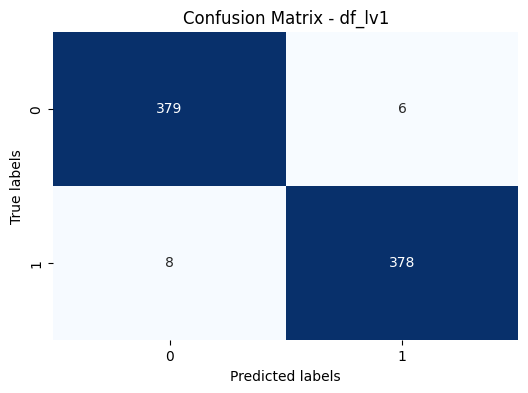

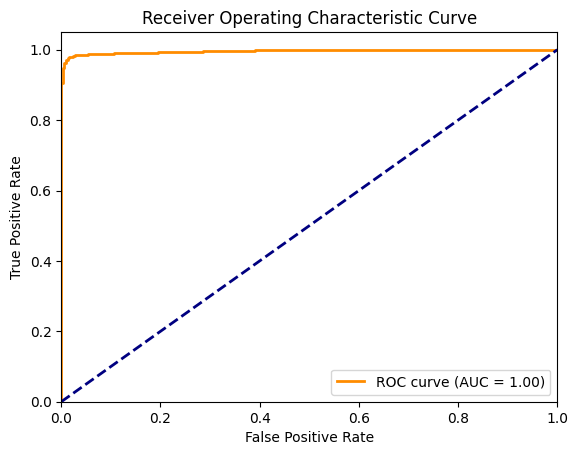

In [ ]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Calculating accuracy with best parameters
accuracy_lv1 = accuracy_score(y_test, y_pred_lv1)
print("Accuracy for df_lv1 with best parameters:", accuracy_lv1)

# Classification report
report_lv1 = classification_report(y_test, y_pred_lv1)
print("Classification report for df_lv1:\n", report_lv1)

# Confusion Matrix visualisation
conf_matrix_lv1 = confusion_matrix(y_test, y_pred_lv1)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_lv1, annot=True, cmap='Blues', fmt='g', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix - df_lv1')
plt.show()

# AUC visualisation
y_score_lv1 = grid_search_lv1.decision_function(x_test) if grid_search_lv1.best_params_['kernel'] == 'linear' else grid_search_lv1.predict_proba(x_test)[:,1]
auc_score_lv1 = roc_auc_score(y_test, y_score_lv1)

# Compute ROC curve
fpr_lv1, tpr_lv1, _ = roc_curve(y_test, y_score_lv1)

# Plot ROC curve
plt.figure()
plt.plot(fpr_lv1, tpr_lv1, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % auc_score_lv1)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc="lower right")
plt.show()


### Level 4 SVM

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define the parameter grid
param_grid_lv4 = {'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001], 'kernel': ['rbf', 'linear']}

# Initialize SVM classifier
svm_lv4 = SVC()

# Initialize GridSearchCV
grid_search_lv4 = GridSearchCV(svm_lv4, param_grid_lv4, refit=True, verbose=2)

# Fit the model
grid_search_lv4.fit(x_train_4, y_train_4)

# Best parameters for the model
print("Best parameters for df_lv4:", grid_search_lv4.best_params_)

# Predicting on the testing set with best parameters
y_pred_lv4 = grid_search_lv4.predict(x_test_4)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.3s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.3s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.3s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.3s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.3s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.3s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.3s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.4s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.4s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.4s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.3s
[CV] END .......................C=0.1, gamma=0.

Accuracy for df_lv4 with best parameters: 0.48249027237354086
Classification report for df_lv4:
               precision    recall  f1-score   support

           0       0.48      0.46      0.47       385
           1       0.48      0.50      0.49       386

    accuracy                           0.48       771
   macro avg       0.48      0.48      0.48       771
weighted avg       0.48      0.48      0.48       771



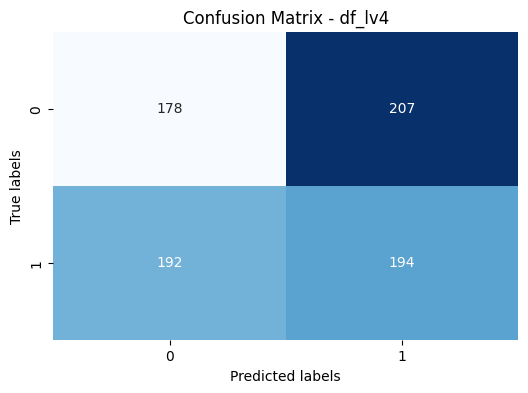

AUC for df_lv4: 0.48246416795639596


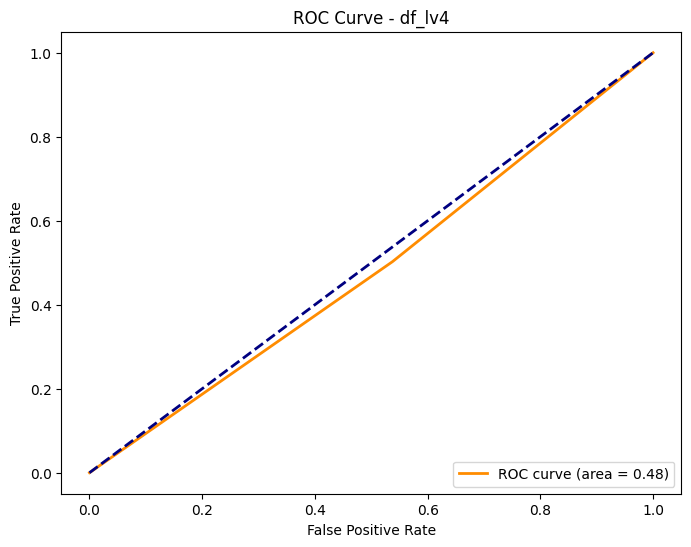

In [ ]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Calculating accuracy with best parameters
accuracy_lv4 = accuracy_score(y_test_4, y_pred_lv4)
print("Accuracy for df_lv4 with best parameters:", accuracy_lv4)

# Classification report
report_lv4 = classification_report(y_test_4, y_pred_lv4)
print("Classification report for df_lv4:\n", report_lv4)

# Confusion matrix visualisation
cm_lv4 = confusion_matrix(y_test_4, y_pred_lv4)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lv4, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix - df_lv4')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

# Calculate AUC
auc_lv4 = roc_auc_score(y_test_4, y_pred_lv4)
print("AUC for df_lv4:", auc_lv4)

# ROC curve
fpr_lv4, tpr_lv4, _ = roc_curve(y_test_4, y_pred_lv4)
plt.figure(figsize=(8, 6))
plt.plot(fpr_lv4, tpr_lv4, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_lv4)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - df_lv4')
plt.legend(loc="lower right")
plt.show()